In [18]:
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
import math
from pathlib import Path

from xarch_tokenizers.logging.report_utils import (
    load_predictions,
    load_all_samples,
    clean_model_name,
)
from xarch_tokenizers.logging.plot_utils import (
    setup_styles,
    get_new_6_fig,
    MODEL_TO_COLOR,
    get_new_fig,
)


setup_styles()
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:


def get_canonical_and_perturbed_df(
    samples,
    only_keep_canonical_true: bool = False,
    keep_remains_or_becomes_correct: bool = False,
    only_keep_perturbed_true: bool = False,
):
    """returns filtered out samples too"""
    if (
        (only_keep_canonical_true and keep_remains_or_becomes_correct)
        or (only_keep_canonical_true and only_keep_perturbed_true)
        or (keep_remains_or_becomes_correct and only_keep_perturbed_true)
    ):
        raise ValueError(
            f"Please pass these exclusively, only_keep_canonical_true: true for canonical, model_name true, keep_remains_or_becomes_correct: True to include the ones where the perturbed version becomes correct"
        )
    print(f"Processing {len(samples)} examples")
    canonical_samples = samples[samples["is_canonical"]]
    perturbed_samples = samples[~samples["is_canonical"]]
    canonical_values = canonical_samples[["set_id", "model_name", METRIC]].rename(
        columns={METRIC: f"canonical_{METRIC}"}
    )

    perturbed_samples = perturbed_samples.merge(
        canonical_values, on=["set_id", "model_name"], how="left"
    )
    perturbed_samples[f"canonical-perturbed_{METRIC}"] = (
        perturbed_samples[f"canonical_{METRIC}"] - perturbed_samples[METRIC]
    )

    if only_keep_canonical_true:
        print(
            f"Cleaning samples, will be dropping entries (set_id-model pairs) where the canonical is predicted wrong."
        )
        correct_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ]
        print(
            f"Keeping {len(correct_canonical_pairs)} correct pairs, dropping {len(canonical_samples) - len(correct_canonical_pairs)} entries."
        )

        canonical_samples = canonical_samples[canonical_samples[METRIC] == 1]

        # Step 3: Filter perturbed_samples to keep only rows with correct canonical pairs
        # Method 1: Using merge (RECOMMENDED)
        perturbed_samples = perturbed_samples.merge(
            correct_canonical_pairs,
            on=["set_id", "model_name"],
            how="inner",  # Only keep rows that exist in both
        )
        samples = pd.concat((canonical_samples, perturbed_samples), ignore_index=True)

    if keep_remains_or_becomes_correct:
        # Get pairs where perturbed samples are correct (becomes or remains correct)
        correct_perturbed_pairs = perturbed_samples[perturbed_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ].drop_duplicates()

        # Get pairs where canonical samples are correct (remains correct)
        correct_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ]

        # Combine: pairs that either remain correct OR become correct
        remains_or_becomes_correct = pd.concat(
            [correct_canonical_pairs, correct_perturbed_pairs]
        ).drop_duplicates()

        # Filter both datasets to only include these pairs
        canonical_samples = canonical_samples.merge(
            remains_or_becomes_correct, on=["set_id", "model_name"], how="inner"
        )

        perturbed_samples = perturbed_samples.merge(
            remains_or_becomes_correct, on=["set_id", "model_name"], how="inner"
        )
        samples = pd.concat((canonical_samples, perturbed_samples), ignore_index=True)
        print(f"After filtering:{len(samples)}")
    if only_keep_perturbed_true:
        # Get pairs where perturbed samples are correct (becomes or remains correct)
        correct_perturbed_pairs = perturbed_samples[perturbed_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ].drop_duplicates()

        # Get pairs where canonical samples are correct (remains correct)
        wrong_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 0][
            ["set_id", "model_name"]
        ]
        # Find cases where canonical wrong AND perturbed correct (recovery cases)
        becomes_correct = pd.merge(
            wrong_canonical_pairs,
            correct_perturbed_pairs,
            how="inner",
            on=["set_id", "model_name"], 
        )
        print(becomes_correct)

        # Filter both datasets to only include recovery cases
        canonical_samples = canonical_samples.merge(
            becomes_correct, on=["set_id", "model_name"], how="inner"
        )
        print(canonical_samples[METRIC].sum())

        perturbed_samples = perturbed_samples.merge(
            becomes_correct, on=["set_id", "model_name"], how="inner"
        )

        samples = pd.concat([canonical_samples, perturbed_samples], ignore_index=True)
        print(f"After filtering: {len(samples)}")

    return samples, canonical_samples, perturbed_samples

## Farsi Subset

In [60]:
METRIC = "acc_norm"
OUTPUT_DIR_ = Path("./output/prelim-results-v3")
OUTPUT_DIR_ = Path("./output/results-v5")

# keeps set_id, model pairs that are correct for canonical
suffix = "(Still correct)"
only_keep_canonical_true = True
keep_remains_or_becomes_correct = False
only_keep_perturbed_true = False

# suffix = "(Remains or Becomes Correct)"
# only_keep_canonical_true = False
# keep_remains_or_becomes_correct = True
# only_keep_perturbed_true = False

# suffix = "(Flipped to correct)"
# only_keep_canonical_true = False
# keep_remains_or_becomes_correct = False
# only_keep_perturbed_true = True

suffix = "(All)" 
only_keep_canonical_true = False
keep_remains_or_becomes_correct = False
only_keep_perturbed_true = False

base_dir = Path("../results/paper").resolve().absolute()
base_dir = Path("../results/paper-v2").resolve().absolute()
code_pattern = "*tokenizer_robustness_completion_farsi*"
title_pattern = "Farsi - "
OUTPUT_DIR = OUTPUT_DIR_/"farsi"

code_pattern = "*tokenizer_robustness_completion_turkish*"
title_pattern = "Turkish - "
OUTPUT_DIR = OUTPUT_DIR_/"turkish"

# code_pattern = "*tokenizer_robustness_completion_stem*"
# title_pattern = "STEM - "
# OUTPUT_DIR = OUTPUT_DIR_/"stem"

# code_pattern = "*tokenizer_robustness_completion_math*"
# title_pattern = "MATH - "
# OUTPUT_DIR = OUTPUT_DIR_/"math"

code_pattern = "*tokenizer_robustness_completion_english*"
title_pattern = "English - "
OUTPUT_DIR = OUTPUT_DIR_/"english"

# code_pattern = "*tokenizer_robustness_completion_chinese*"
# title_pattern = "Chinese - "
# OUTPUT_DIR = OUTPUT_DIR_/"chinese"

# code_pattern = "*tokenizer_robustness_completion_italian*"
# title_pattern = "Italian - "

# # OUTPUT_DIR = OUTPUT_DIR_/"italian"
# code_pattern = "*"
# title_pattern = "All Datasets"
# OUTPUT_DIR = OUTPUT_DIR_/"all"

SUFFIX = suffix.lower().replace("(","").replace(")","")
OUTPUT_DIR = OUTPUT_DIR/SUFFIX
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
base_dir = Path("../results/paper-v5").resolve().absolute()
base_dir.exists()
pred_files = list([p for p in base_dir.rglob(f"samples{code_pattern}.jsonl")])
len(pred_files), pred_files[:5]


(406,
 [PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_contractions_2025-09-20T00-37-11.241572.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_emoji_substitution_2025-09-20T00-37-11.241572.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_spaced_styling_2025-09-20T00-37-11.241572.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_homoglyphs_2025-09-20T00-37-11.241572.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/

In [ ]:
all_samples = load_all_samples(
    base_dir,
    patterns=[code_pattern],
    flatten_doc=True,
    match_date=False,
    simplify_df=True,
)

task_counts = all_samples.groupby("task")["model_name"].value_counts().groupby(level=0).mean()
valid_tasks = task_counts[task_counts>=5].index
all_samples = all_samples[all_samples["task"].isin(valid_tasks)]
all_samples["is_canonical"] = (
    all_samples["variation_id"].apply(lambda x: str(x).split(".")[1]) == "0"
)
## exclude anything that is mistaken
all_samples = all_samples[all_samples["subcategories"] != "Turkish, Numerical formats"]
all_samples = all_samples[all_samples["task"] != "tokenizer_robustness_completion_english_space_additions"]
valid_tasks = all_samples.pivot_table(index=["model_name", "task"], values=METRIC, aggfunc="count")
all_samples = all_samples
## filter based on settings specified above
samples, canonical_df, perturbed_df = get_canonical_and_perturbed_df(
    all_samples,
    only_keep_canonical_true=only_keep_canonical_true,
    keep_remains_or_becomes_correct=keep_remains_or_becomes_correct,
    only_keep_perturbed_true=only_keep_perturbed_true,
)

samples.head()
samples["subcategories"].value_counts()
all_samples["set_id"].value_counts()

406 [PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_contractions_2025-09-20T00-37-11.241572.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_emoji_substitution_2025-09-20T00-37-11.241572.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_spaced_styling_2025-09-20T00-37-11.241572.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_homoglyphs_2025-09-20T00-37-11.241572.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tok

set_id
303.0    644
300.0    462
301.0    462
308.0    434
312.0    420
304.0    420
327.0    420
333.0    406
315.0    406
313.0    406
344.0    406
302.0    406
305.0    406
306.0    392
329.0    392
309.0    392
307.0    392
316.0    392
337.0    392
323.0    392
335.0    392
310.0    392
328.0    392
338.0    378
311.0    378
339.0    378
340.0    378
341.0    378
342.0    378
336.0    378
330.0    378
331.0    378
326.0    378
322.0    378
314.0    378
332.0    364
317.0    364
343.0    364
324.0    364
334.0    350
Name: count, dtype: int64

In [62]:
pv = all_samples.pivot_table(index=["model_name", "is_canonical"], values=METRIC)
pv.to_csv(OUTPUT_DIR/f"model_canonical_{METRIC}.csv")
pv

acc_norm
model_name   is_canonical          
Aya          False         0.709091
             True          0.975000
BLOOM        False         0.731818
             True          1.000000
ByT5         False         0.686364
             True          0.900000
Comma        False         0.737273
             True          0.950000
GPT-2        False         0.718182
             True          0.950000
GPT-4o       False         0.714545
             True          0.925000
Gemma-2      False         0.714545
             True          0.975000
Llama-3.2    False         0.731818
             True          1.000000
Phi-3        False         0.682727
             True          0.950000
Qwen-3       False         0.702727
             True          0.950000
Tekken       False         0.703636
             True          0.950000
TokenMonster False         0.677273
             True          0.875000
XGLM         False         0.761818
             True          0.950000
mBERT        False         0.699091
             True          0.925000

              acc_norm
model_name            
Aya           0.718421
BLOOM         0.741228
ByT5          0.693860
Comma         0.744737
GPT-2         0.726316
GPT-4o        0.721930
Gemma-2       0.723684
Llama-3.2     0.741228
Phi-3         0.692105
Qwen-3        0.711404
Tekken        0.712281
TokenMonster  0.684211
XGLM          0.768421
mBERT         0.707018


/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_20288/3737008612.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(accuracies_by_model, x=XAXIS, y=METRIC, palette=palette)


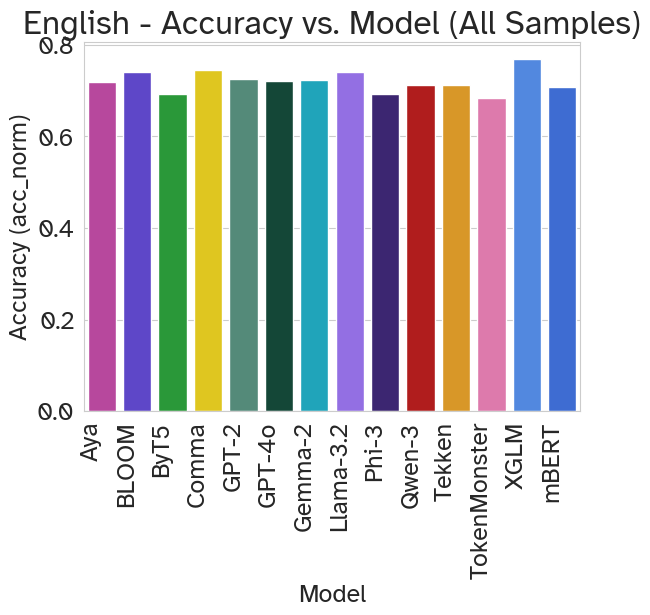

In [74]:
### Here using ALL SAMPLES

XAXIS = "model_name"
palette=MODEL_TO_COLOR
# XAXIS = "vocab_bucket"
# palette=None
accuracies_by_model = all_samples.pivot_table(
    index=XAXIS, values=METRIC, aggfunc="mean"
)
sns.barplot(accuracies_by_model, x=XAXIS, y=METRIC, palette=palette)
# sns.barplot(accuracies_by_model, x=XAXIS, y=METRIC, palette=MODEL_TO_COLOR)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel(f"Accuracy ({METRIC})")
plt.title(f"{title_pattern}Accuracy vs. Model (All Samples)")
plt.savefig(OUTPUT_DIR/f"all_samples_{METRIC}.pdf", pad_inches=0, bbox_inches="tight")

print(accuracies_by_model)

In [64]:
samples["vocab_bucket"]

15301     Large
15435     Large
15875     Large
14820     Large
15259     Large
          ...  
12539    Medium
12216    Medium
11974    Medium
12499    Medium
11838    Medium
Name: vocab_bucket, Length: 15960, dtype: object

### Canonical vs. Pertuerbed

                           acc_norm
model_name   is_canonical          
Aya          False         0.709091
             True          0.975000
BLOOM        False         0.731818
             True          1.000000
ByT5         False         0.686364
             True          0.900000
Comma        False         0.737273
             True          0.950000
GPT-2        False         0.718182
             True          0.950000
GPT-4o       False         0.714545
             True          0.925000
Gemma-2      False         0.714545
             True          0.975000
Llama-3.2    False         0.731818
             True          1.000000
Phi-3        False         0.682727
             True          0.950000
Qwen-3       False         0.702727
             True          0.950000
Tekken       False         0.703636
             True          0.950000
TokenMonster False         0.677273
             True          0.875000
XGLM         False         0.761818
             True          0

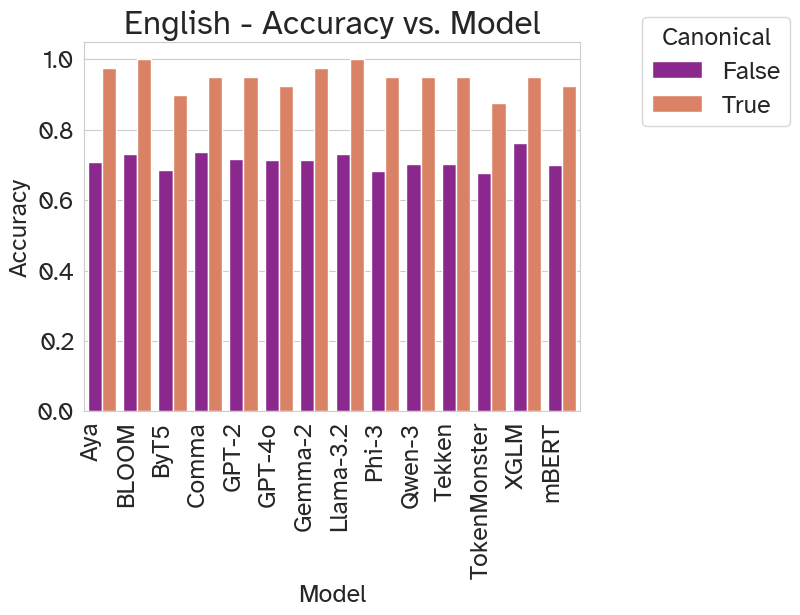

In [65]:
accuracies_by_model = all_samples.pivot_table(
    index=["model_name", "is_canonical"], values=METRIC, aggfunc="mean"
)
# sns.barplot(accuracies_by_model, x="is_canonical", y=METRIC, hue="model_name", palette=MODEL_TO_COLOR)
# xlabel = "Canonical"
sns.barplot(accuracies_by_model, x="model_name", y=METRIC, hue="is_canonical", palette="plasma")
xlabel = "Model"
plt.xticks(rotation=90, ha="right")
plt.xlabel(xlabel)
plt.ylabel("Accuracy")
plt.title(f"{title_pattern}Accuracy vs. Model")
plt.legend(bbox_to_anchor=(1.1, 1.1), title="Canonical")
plt.savefig(OUTPUT_DIR/f"canonical_vs_perturbed_{METRIC}.pdf", pad_inches=0, bbox_inches="tight")

print(accuracies_by_model)

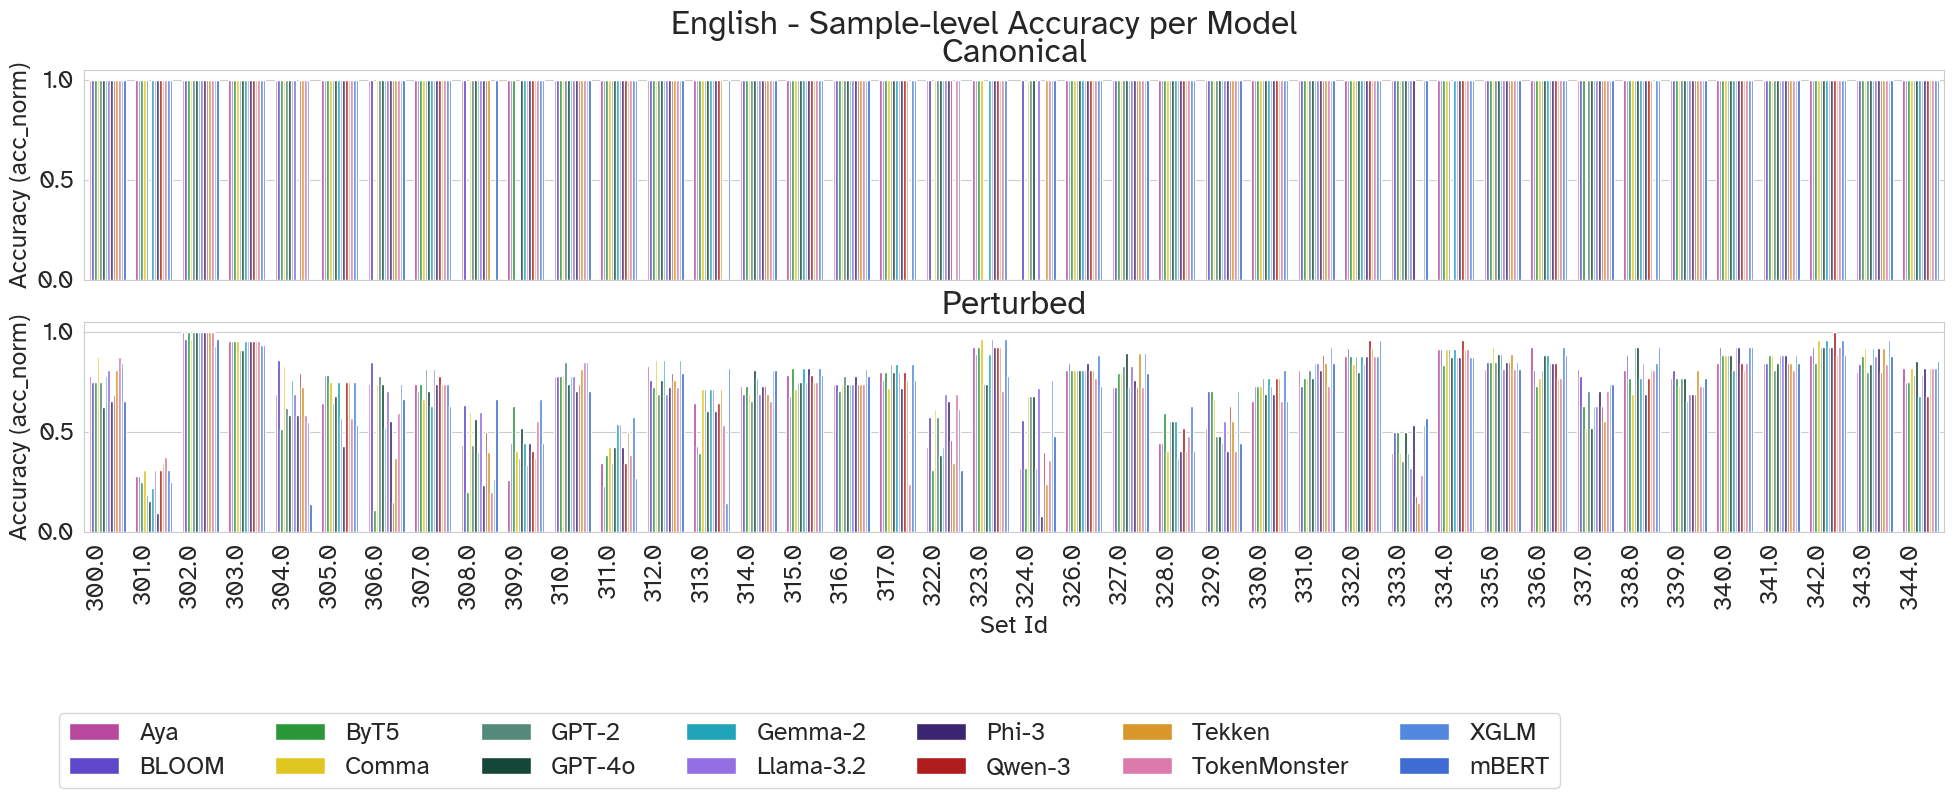

In [75]:
accuracies_by_model = all_samples.copy()
accuracies_by_model = all_samples.pivot_table(
    index=["set_id", "model_name", "is_canonical"], values=METRIC, aggfunc="mean"
).reset_index()
fig, axs = plt.subplots(2, 1, figsize=(24, 6), sharex=True)
axs = axs.flat
sns.barplot(
    accuracies_by_model[accuracies_by_model["is_canonical"]],
    x="set_id",
    y=METRIC,
    hue="model_name",
    palette=MODEL_TO_COLOR,
    ax=axs[0],
    legend=False,
)
axs[0].set_title("Canonical")
axs[1].set_title("Perturbed")

sns.barplot(
    accuracies_by_model[~accuracies_by_model["is_canonical"]],
    x="set_id",
    y=METRIC,
    hue="model_name",
    palette=MODEL_TO_COLOR,
    ax=axs[1],
    legend=True,
)
axs[1].legend(bbox_to_anchor=(0.8, -0.8, 0, 0), ncol=7)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Set Id")
axs[0].set_ylabel(f"Accuracy ({METRIC})")
axs[1].set_ylabel(f"Accuracy ({METRIC})")
# Specify the questions
fig.suptitle(f"{title_pattern}Sample-level Accuracy per Model")
plt.savefig(OUTPUT_DIR/f"by_samples_canonical_vs_perturbed.pdf", pad_inches=0, bbox_inches="tight")

plt.show()

                                          acc_norm
model_name task_pretty_name                       
Aya        Abbreviations                  0.702703
           Canonical                      0.975000
           Capitalization                 0.825000
           Character deletion             0.800000
           Character substitution         1.000000
...                                            ...
mBERT      Spaced styling                 0.375000
           Spelled out                    0.600000
           Superscript/subscript styling  0.325000
           Web search query               0.621622
           Word reordering                0.850000

[406 rows x 1 columns]


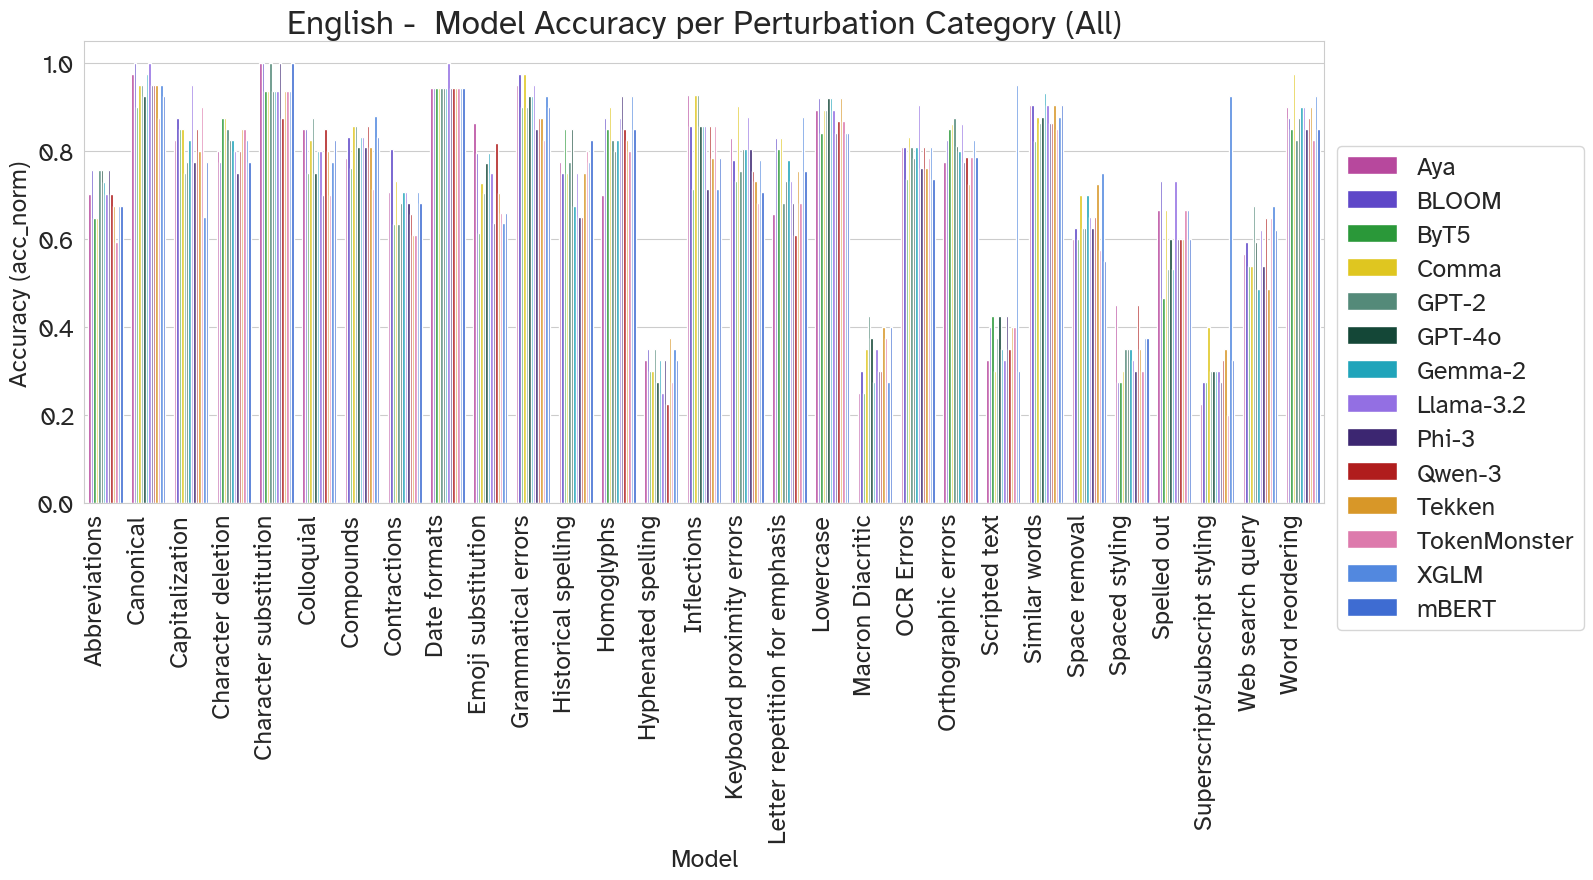

In [77]:
from xarch_tokenizers.logging.plot_utils import MODEL_TO_COLOR

accuracies_by_model = samples.pivot_table(
    index=["model_name", "task_pretty_name"], values=METRIC, aggfunc="mean"
)
fig, axs = plt.subplots(1, 1, figsize=(16, 6))
sns.barplot(
    accuracies_by_model,
    x="task_pretty_name",
    y=METRIC,
    hue="model_name",
    # palette="viridis",
    palette=MODEL_TO_COLOR,
)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel(f"Accuracy ({METRIC})")
plt.title(f"{title_pattern} Model Accuracy per Perturbation Category {suffix}")
plt.legend(bbox_to_anchor=(1, 0.8))
plt.savefig(OUTPUT_DIR/f"combined_{METRIC}.pdf", pad_inches=0, bbox_inches="tight")

print(accuracies_by_model)

In [68]:
samples.sort_values(["category"])["category"].unique()

array(['', 'Grammatical errors', 'Mathematical & Scientific Notation',
       'Mathematical & Scientific Notation, Context-Dependent Ambiguities',
       'Morphological Challenges',
       'Morphological Challenges, Mathematical & Scientific Notation',
       'Morphological Challenges, Script / Orthography, Context-Dependent Ambiguities',
       'Noise', 'Script / Orthography',
       'Script / Orthography, Context-Dependent Ambiguities',
       'Script / Orthography, Language Contact',
       'Script / Orthography, Language Contact, Script / Orthography',
       'Script / Orthography, Mathematical & Scientific Notation',
       'Script / Orthography, Morphological Challenges',
       'Social Media & Informal Text', 'Structural Text Elements',
       'Temporal Expressions'], dtype=object)

Plotting Canonical into position 1
1 False False
Plotting Grammatical errors into position 2
2 False False
Plotting Spelled out into position 3
3 False False
Plotting Compounds into position 4
4 False False
Plotting Inflections into position 5
5 False False
Plotting Contractions into position 6
6 False False
Plotting Keyboard proximity errors into position 7
7 False False
Plotting OCR Errors into position 8
8 False True


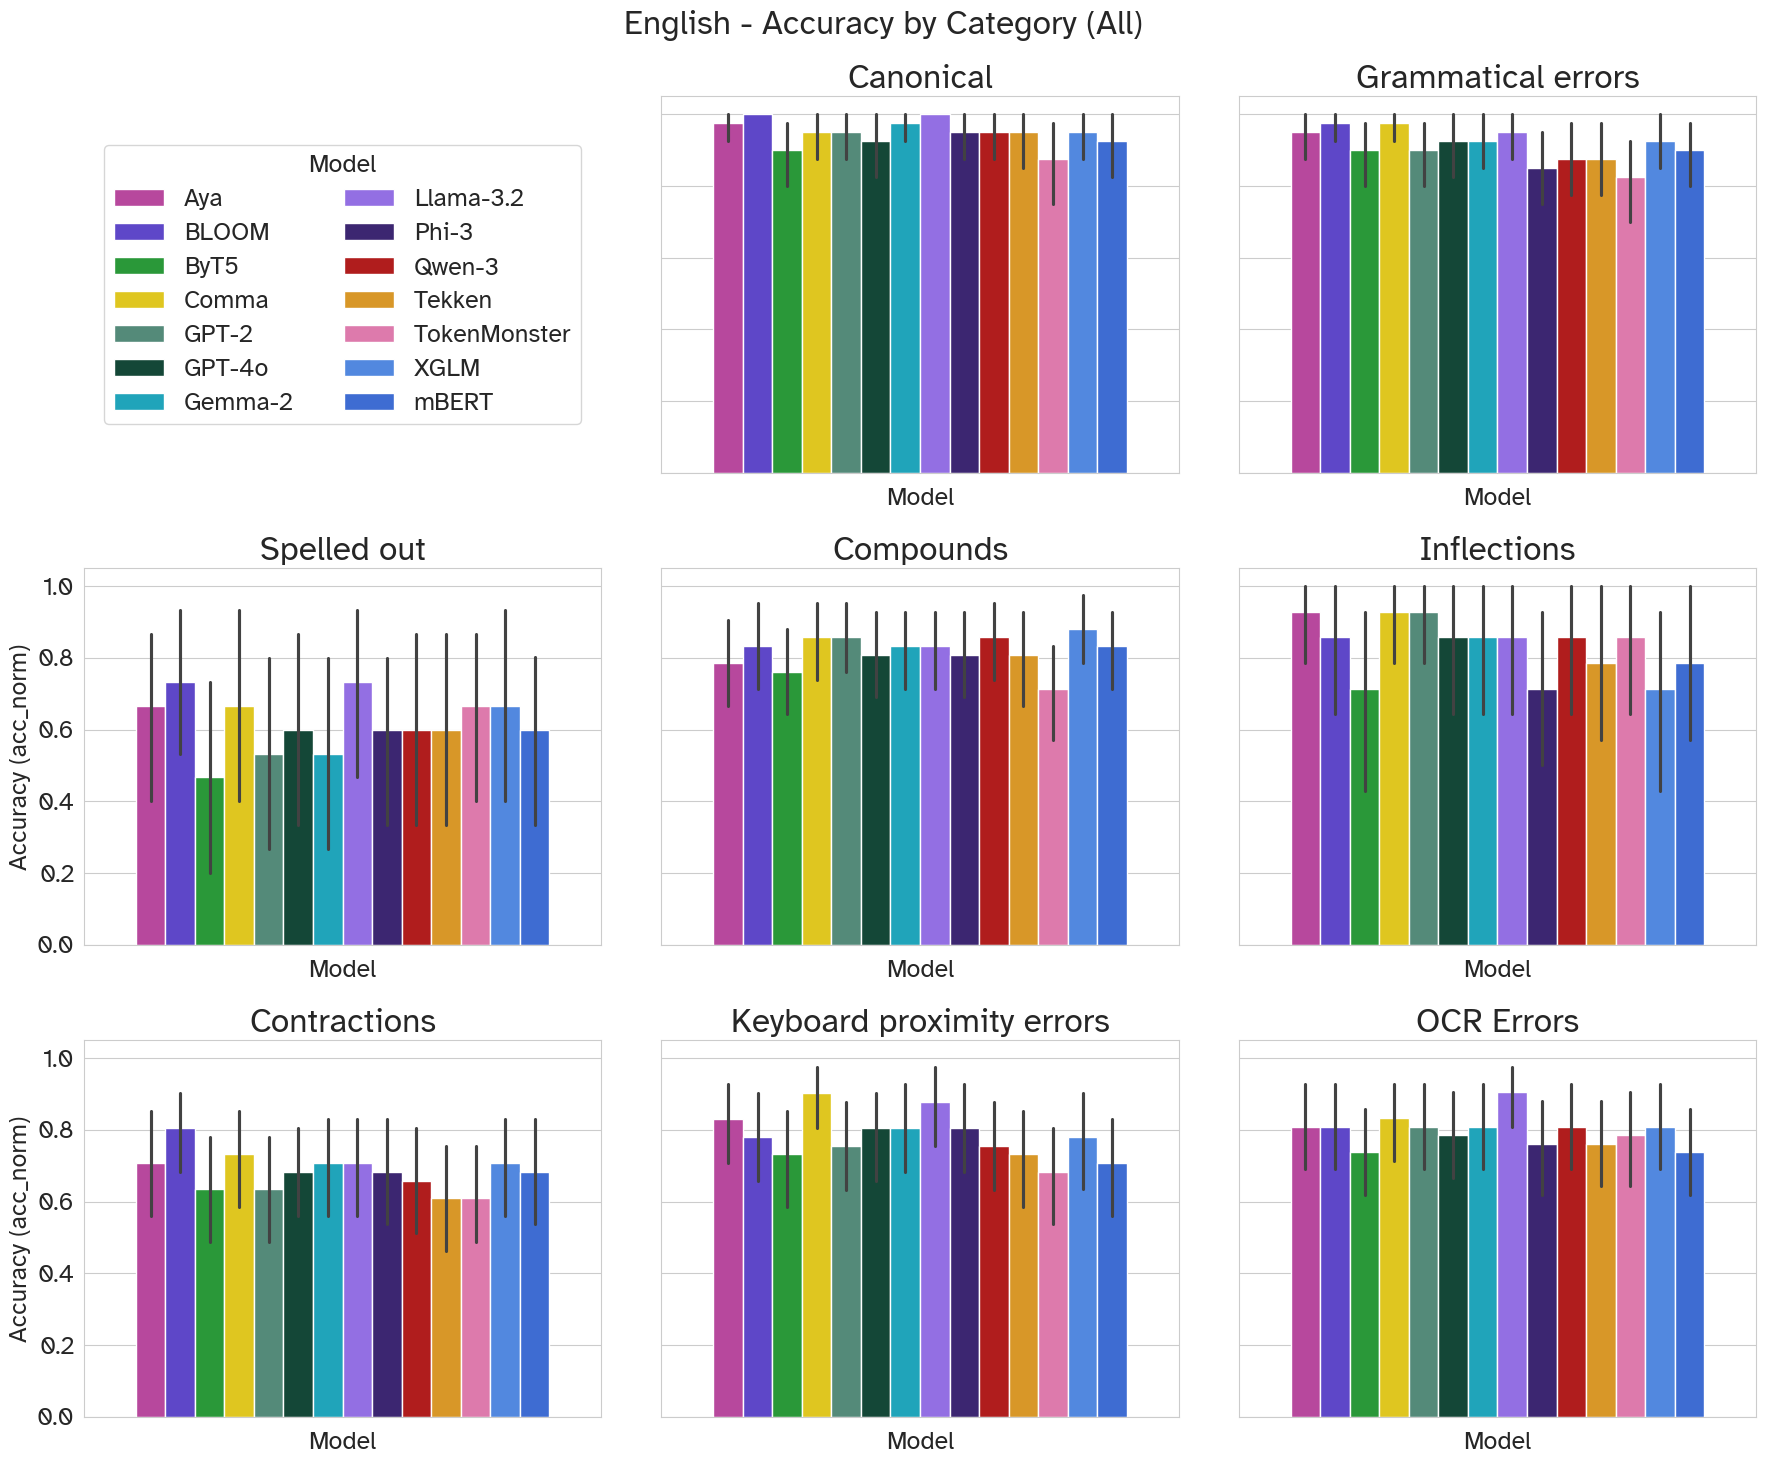

Plotting Space removal into position 0
9 False False
Plotting Character deletion into position 1
10 False False
Plotting Historical spelling into position 2
11 False False
Plotting Homoglyphs into position 3
12 False False
Plotting Abbreviations into position 4
13 False False
Plotting Orthographic errors into position 5
14 False False
Plotting Similar words into position 6
15 False False
Plotting Web search query into position 7
16 False False
Plotting Emoji substitution into position 8
17 False True


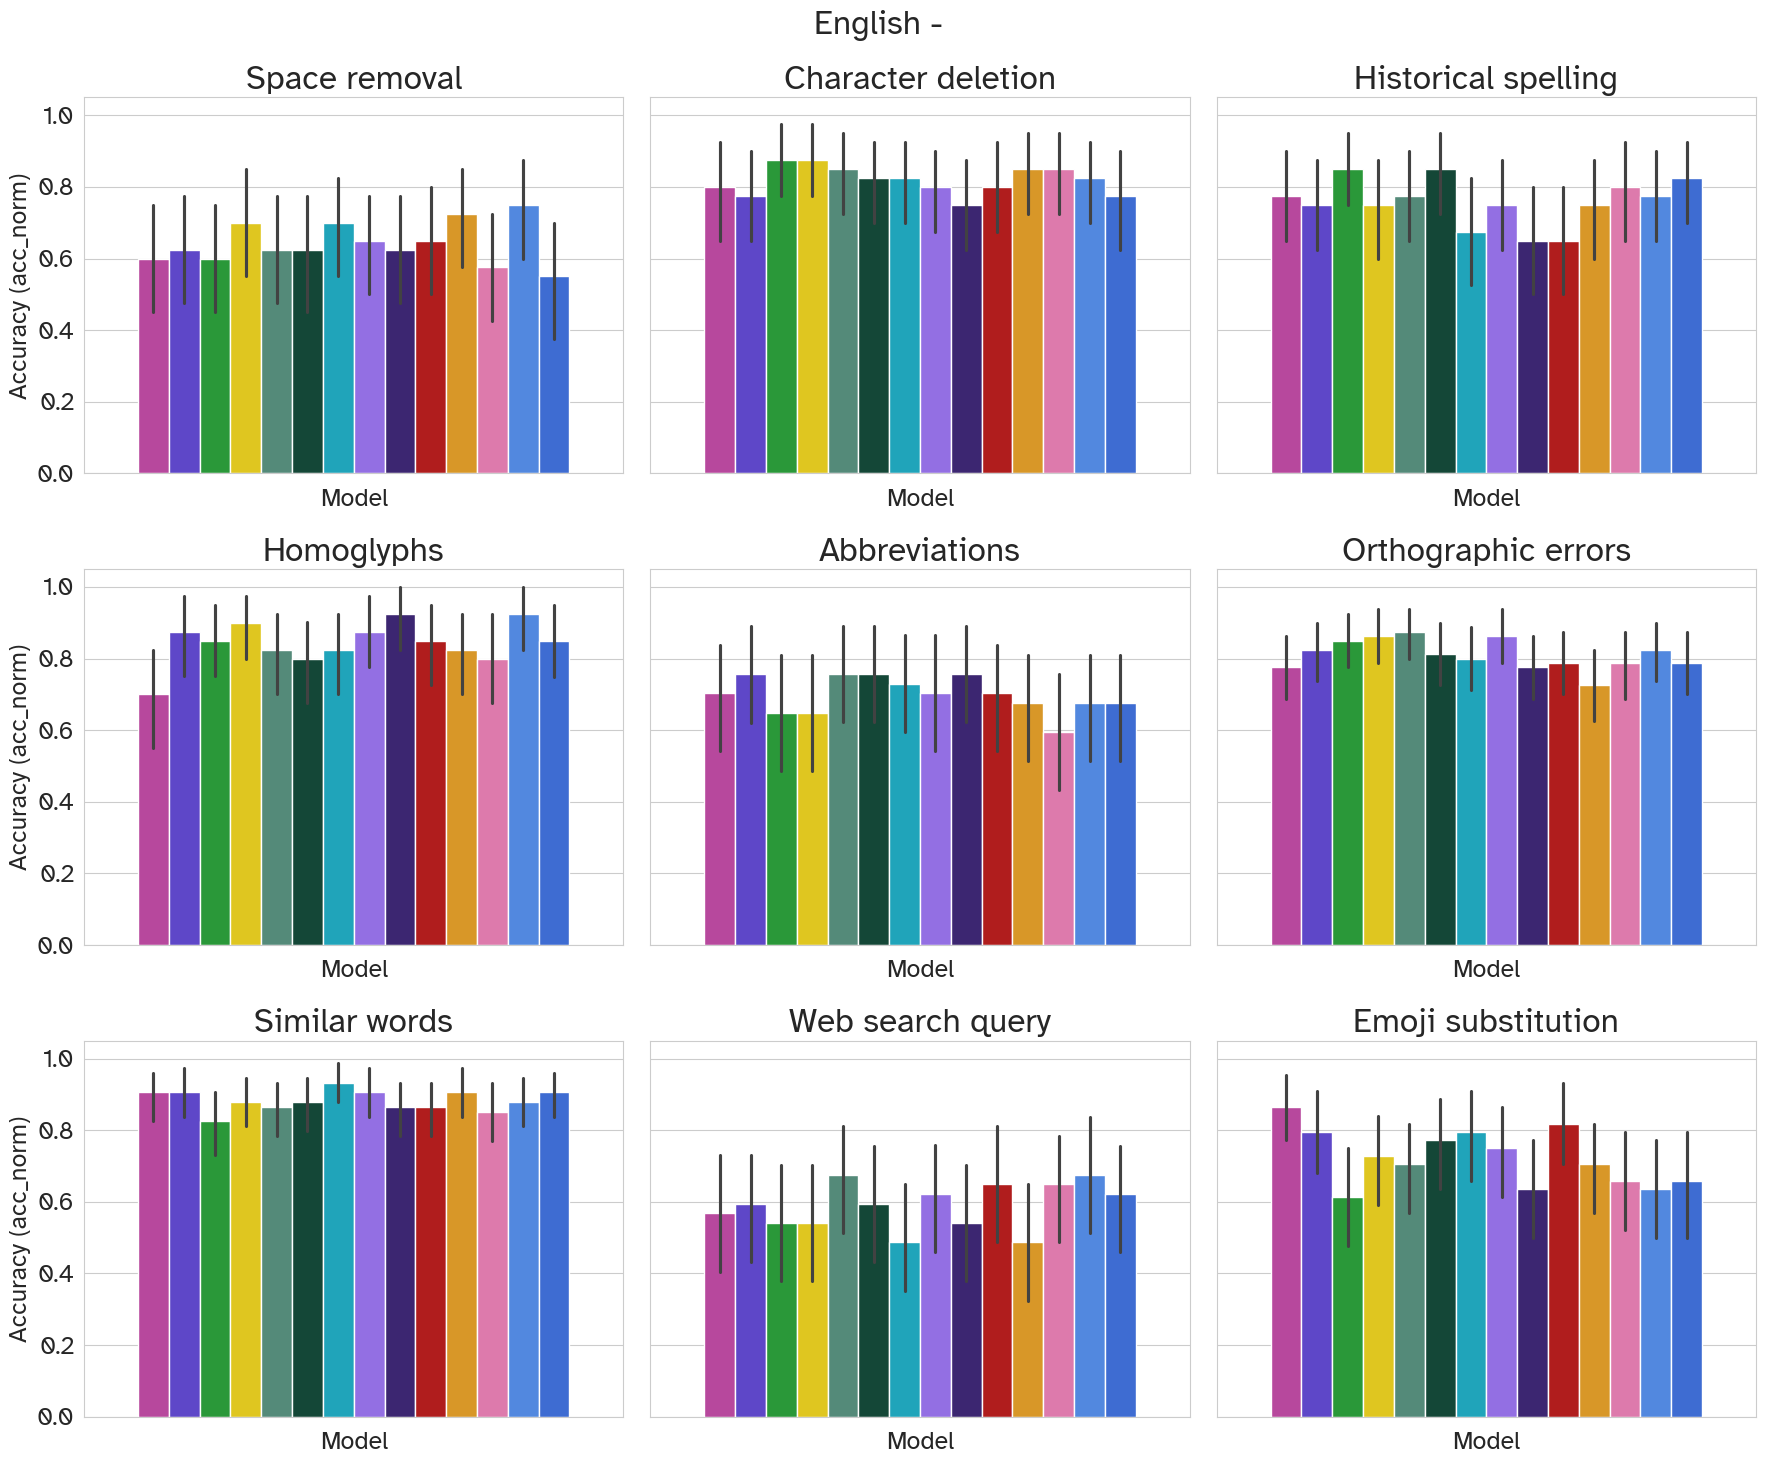

Plotting Letter repetition for emphasis into position 0
18 False False
Plotting Word reordering into position 1
19 False False
Plotting Colloquial into position 2
20 False False
Plotting Character substitution into position 3
21 False False
Plotting Hyphenated spelling into position 4
22 False False
Plotting Lowercase into position 5
23 False False
Plotting Macron Diacritic into position 6
24 False False
Plotting Scripted text into position 7
25 False False
Plotting Spaced styling into position 8
26 False True


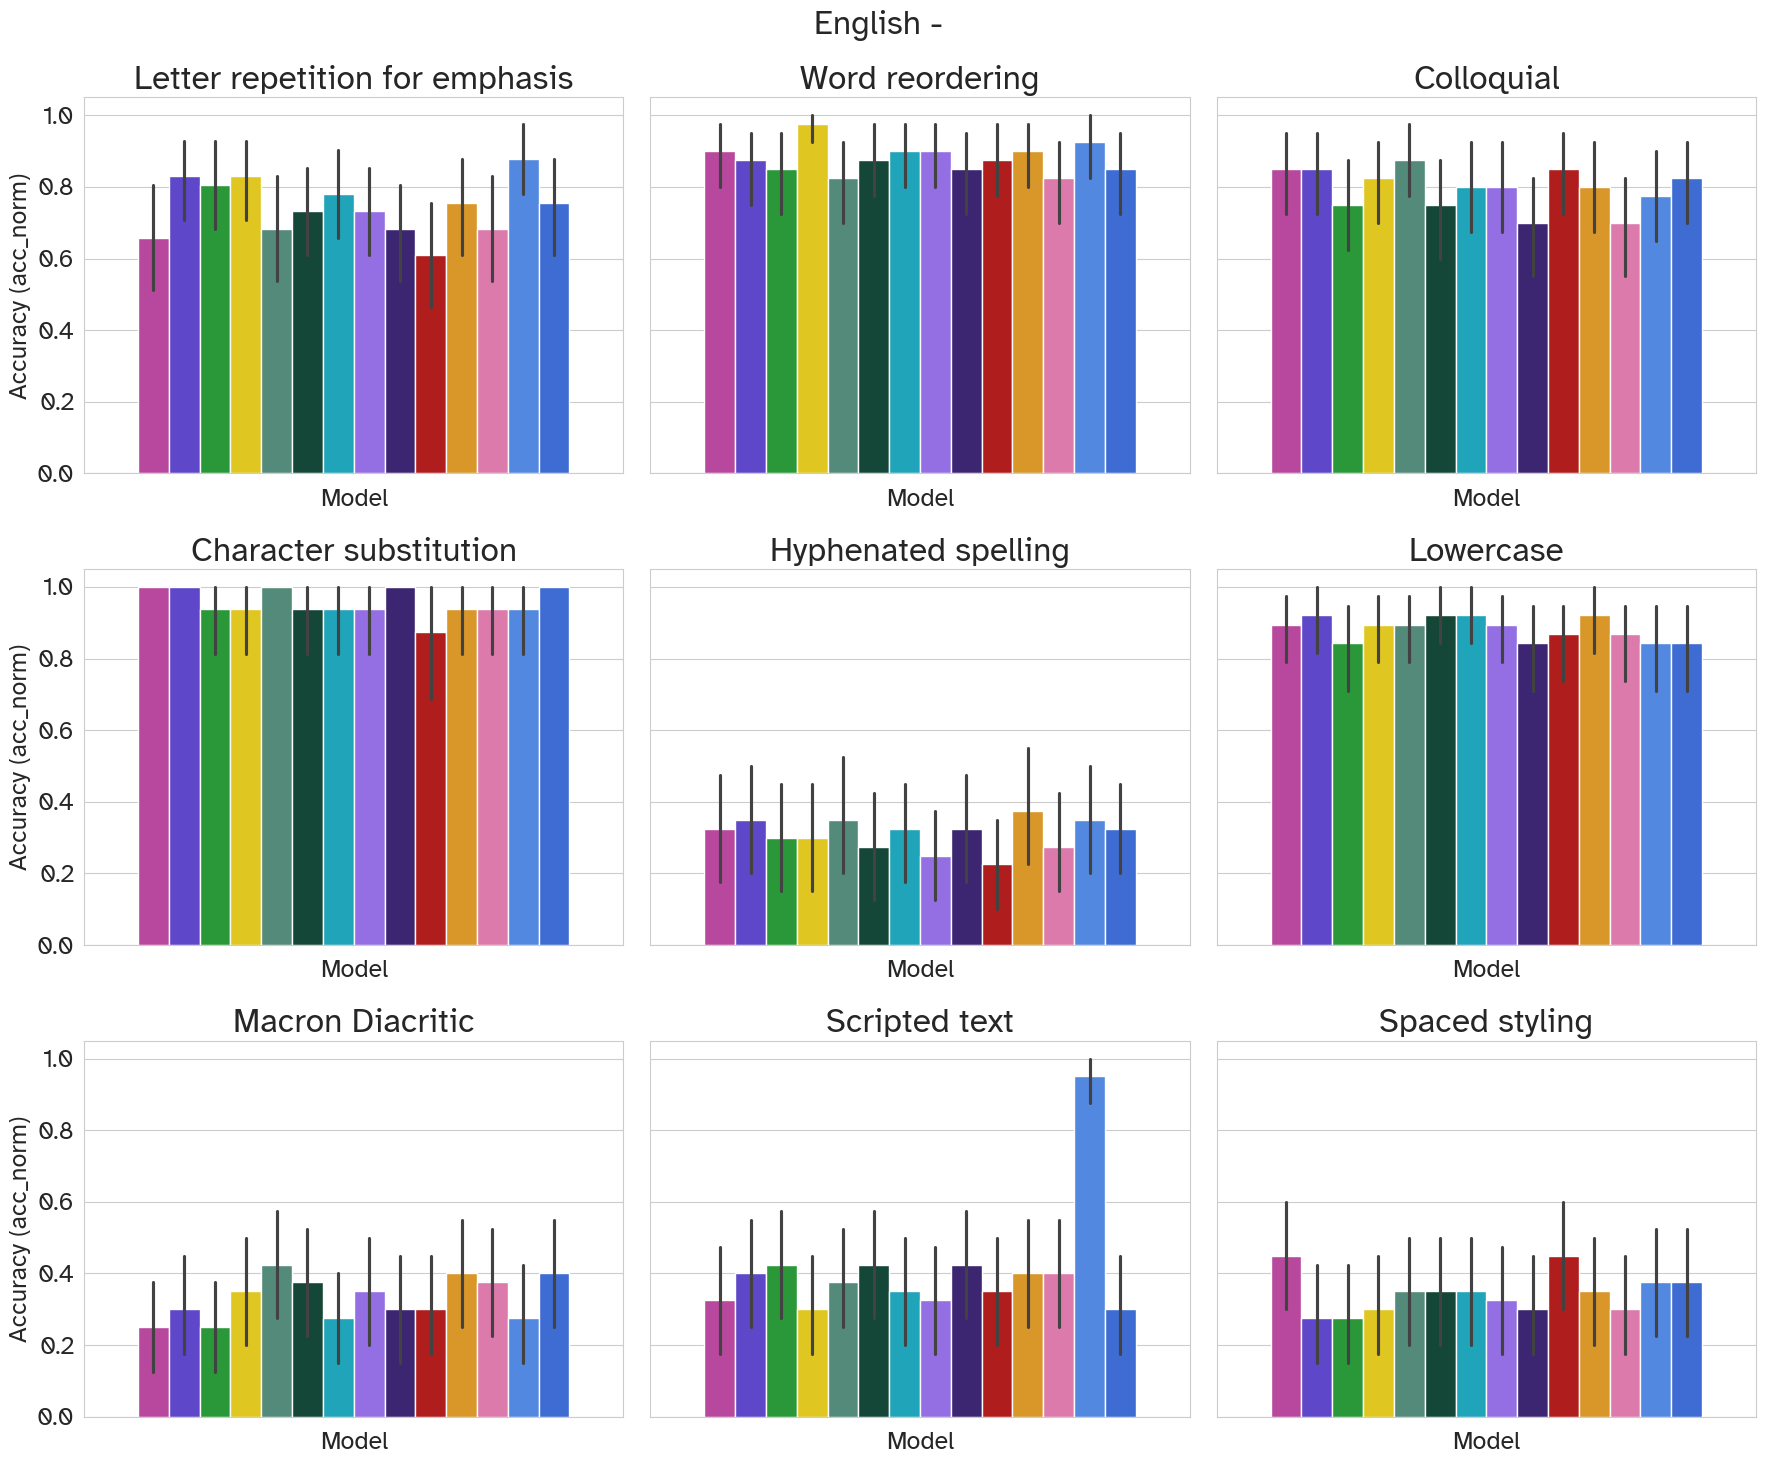

Plotting Superscript/subscript styling into position 0
27 False False
Plotting Capitalization into position 1
28 False False
Plotting Date formats into position 2
29 False False


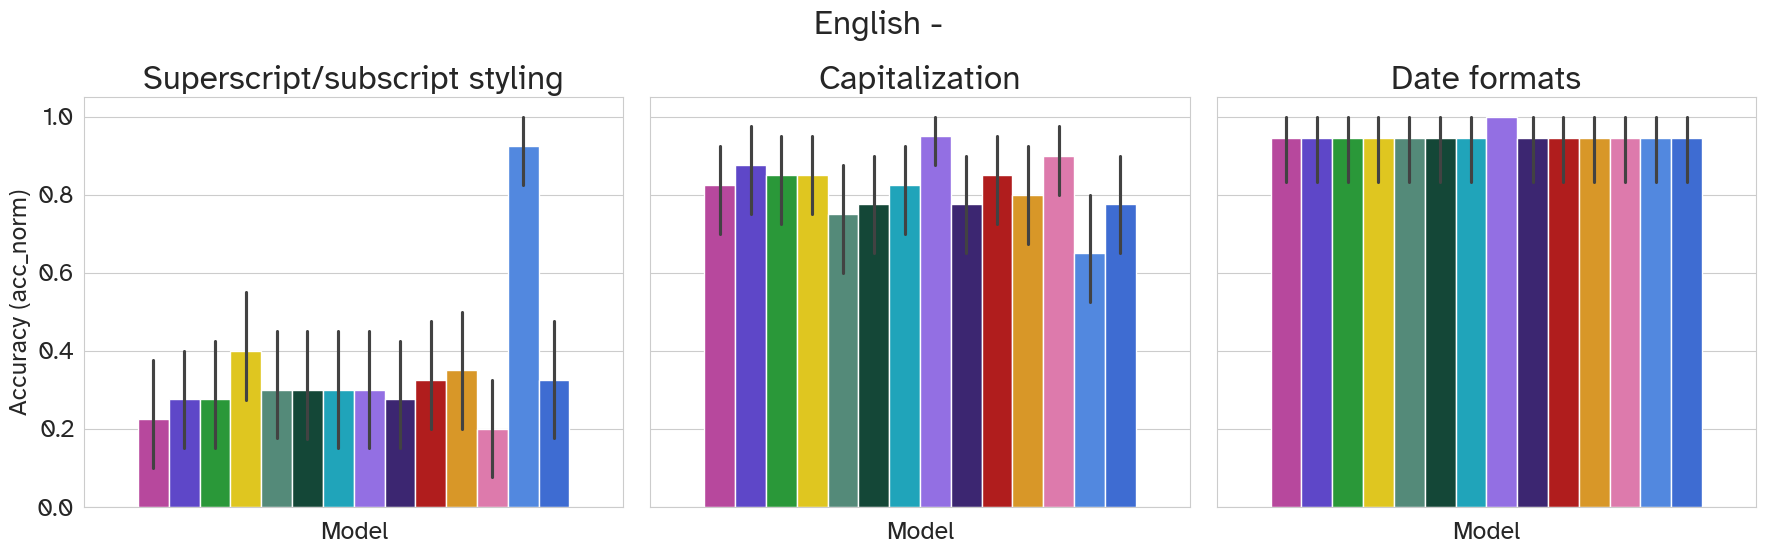

                                          acc_norm
model_name task_pretty_name                       
Aya        Abbreviations                  0.702703
           Canonical                      0.975000
           Capitalization                 0.825000
           Character deletion             0.800000
           Character substitution         1.000000
...                                            ...
mBERT      Spaced styling                 0.375000
           Spelled out                    0.600000
           Superscript/subscript styling  0.325000
           Web search query               0.621622
           Word reordering                0.850000

[406 rows x 1 columns]


In [79]:
nrows, ncols = 3, 3
fig, axs = get_new_fig(
    nrows=nrows, ncols=ncols, title=f"{title_pattern}Accuracy by Category {suffix}"
)
fig_cnt = 0
PLOT_AXIS = "model_name"
# PLOT_AXIS = "vocab_bucket"
palette = MODEL_TO_COLOR if PLOT_AXIS == "model_name" else None

samples = samples.sort_values(["model_name", "category", "set_id", "variation_id"])
samples = samples.sort_values(["model_name", "category"])
tasks = samples["task_pretty_name"].unique()
# tasks = tasks[1:]

for i, task in enumerate(tasks, 1):
    print(f"Plotting {task} into position {i % len(axs)}")
    filter_ = samples["task_pretty_name"] == task
    tmp = samples[filter_]
    ax = axs[i % len(axs)]
    sns.barplot(
        tmp, hue=PLOT_AXIS, y=METRIC,ax=ax, legend=i == 1, palette=palette
    )
    ax.set_xlabel("Model")
    ax.set_ylabel(f"Accuracy ({METRIC})")
    title = task
    ax.set_title(title)
    # Check if we need to show the current figure
    is_last_task = i == len(tasks) + 1
    is_end_of_6 = (i + 1) % (nrows * ncols) == 0
    if i == 1:
        # Add legend to the first subplot of current figure
        handles, labels = axs[1].get_legend_handles_labels()
        axs[0].clear()
        axs[0].axis("off")
        axs[0].legend(handles, labels, title="Model", loc="center", ncol=2)
        axs[1].legend().set_visible(False)
    print(i, is_last_task, is_end_of_6)
    if is_last_task or is_end_of_6:
        # Hide any unused subplots in the current figure
        if is_last_task:
            print(f"Last task: {i}, {task}")
            num_plots_in_current_fig = (i % ncols * nrows) + 1
            for j in range(num_plots_in_current_fig, ncols * nrows):
                axs[j].set_visible(False)
            break

        # Show the current figure
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR/f"by_task_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
        plt.show()
        fig, axs = get_new_fig(nrows=nrows, ncols=ncols, title=title_pattern)
        fig_cnt += 1
# Hide any unused subplots if there are fewer than 6 tasks
for j in range((len(tasks) + 1) % (ncols * nrows), ncols * nrows):
    axs[j].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig(OUTPUT_DIR/f"by_task_by_{PLOT_AXIS.lower()}_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
plt.show()

print(accuracies_by_model)

In [70]:
samples[samples["task_pretty_name"] == "Contractions"]["question"]

15919       Dr Smith's a doctor. Occupation of Dr Smith is
15920                                   The color of sky's
15921         This house's 1,028,415 dollars. This house's
15922                  Today's date is 29/08/2025. Today's
15923                  The number of continents on Earth's
                               ...                        
12455                          "Romeo and Juliet" author's
12456         What plants need from the air to make food's
12457                                  What bees produce's
12458    In "Can you please book a flight to Paris?", t...
12459    In "Can you please book a flight to Paris?", t...
Name: question, Length: 574, dtype: object

In [71]:
# print(samples.pivot_table(index=["category", "task_pretty_name", "model_name"], values=METRIC, aggfunc="count")["Qwen"].to_markdown())
pv = samples.pivot_table(index=["model_name", "task_pretty_name"], values=METRIC, aggfunc="count")
# ["mBERT"]
pv = pv.loc["Aya"]
pv

print(pv.to_markdown())


| task_pretty_name               |   acc_norm |
|:-------------------------------|-----------:|
| Abbreviations                  |         37 |
| Canonical                      |         40 |
| Capitalization                 |         40 |
| Character deletion             |         40 |
| Character substitution         |         16 |
| Colloquial                     |         40 |
| Compounds                      |         42 |
| Contractions                   |         41 |
| Date formats                   |         18 |
| Emoji substitution             |         44 |
| Grammatical errors             |         40 |
| Historical spelling            |         40 |
| Homoglyphs                     |         40 |
| Hyphenated spelling            |         40 |
| Inflections                    |         14 |
| Keyboard proximity errors      |         41 |
| Letter repetition for emphasis |         41 |
| Lowercase                      |         38 |
| Macron Diacritic               |      

## By Category

Plotting  into position 1
1 False False
Plotting Morphological Challenges into position 2
2 False False
Plotting Social Media & Informal Text into position 3
3 False False
Plotting Grammatical errors into position 4
4 False False
Plotting Script / Orthography into position 5
5 False False
Plotting Structural Text Elements into position 6
6 False False
Plotting Noise into position 7
7 False False
Plotting Script / Orthography, Context-Dependent Ambiguities into position 8
8 False True


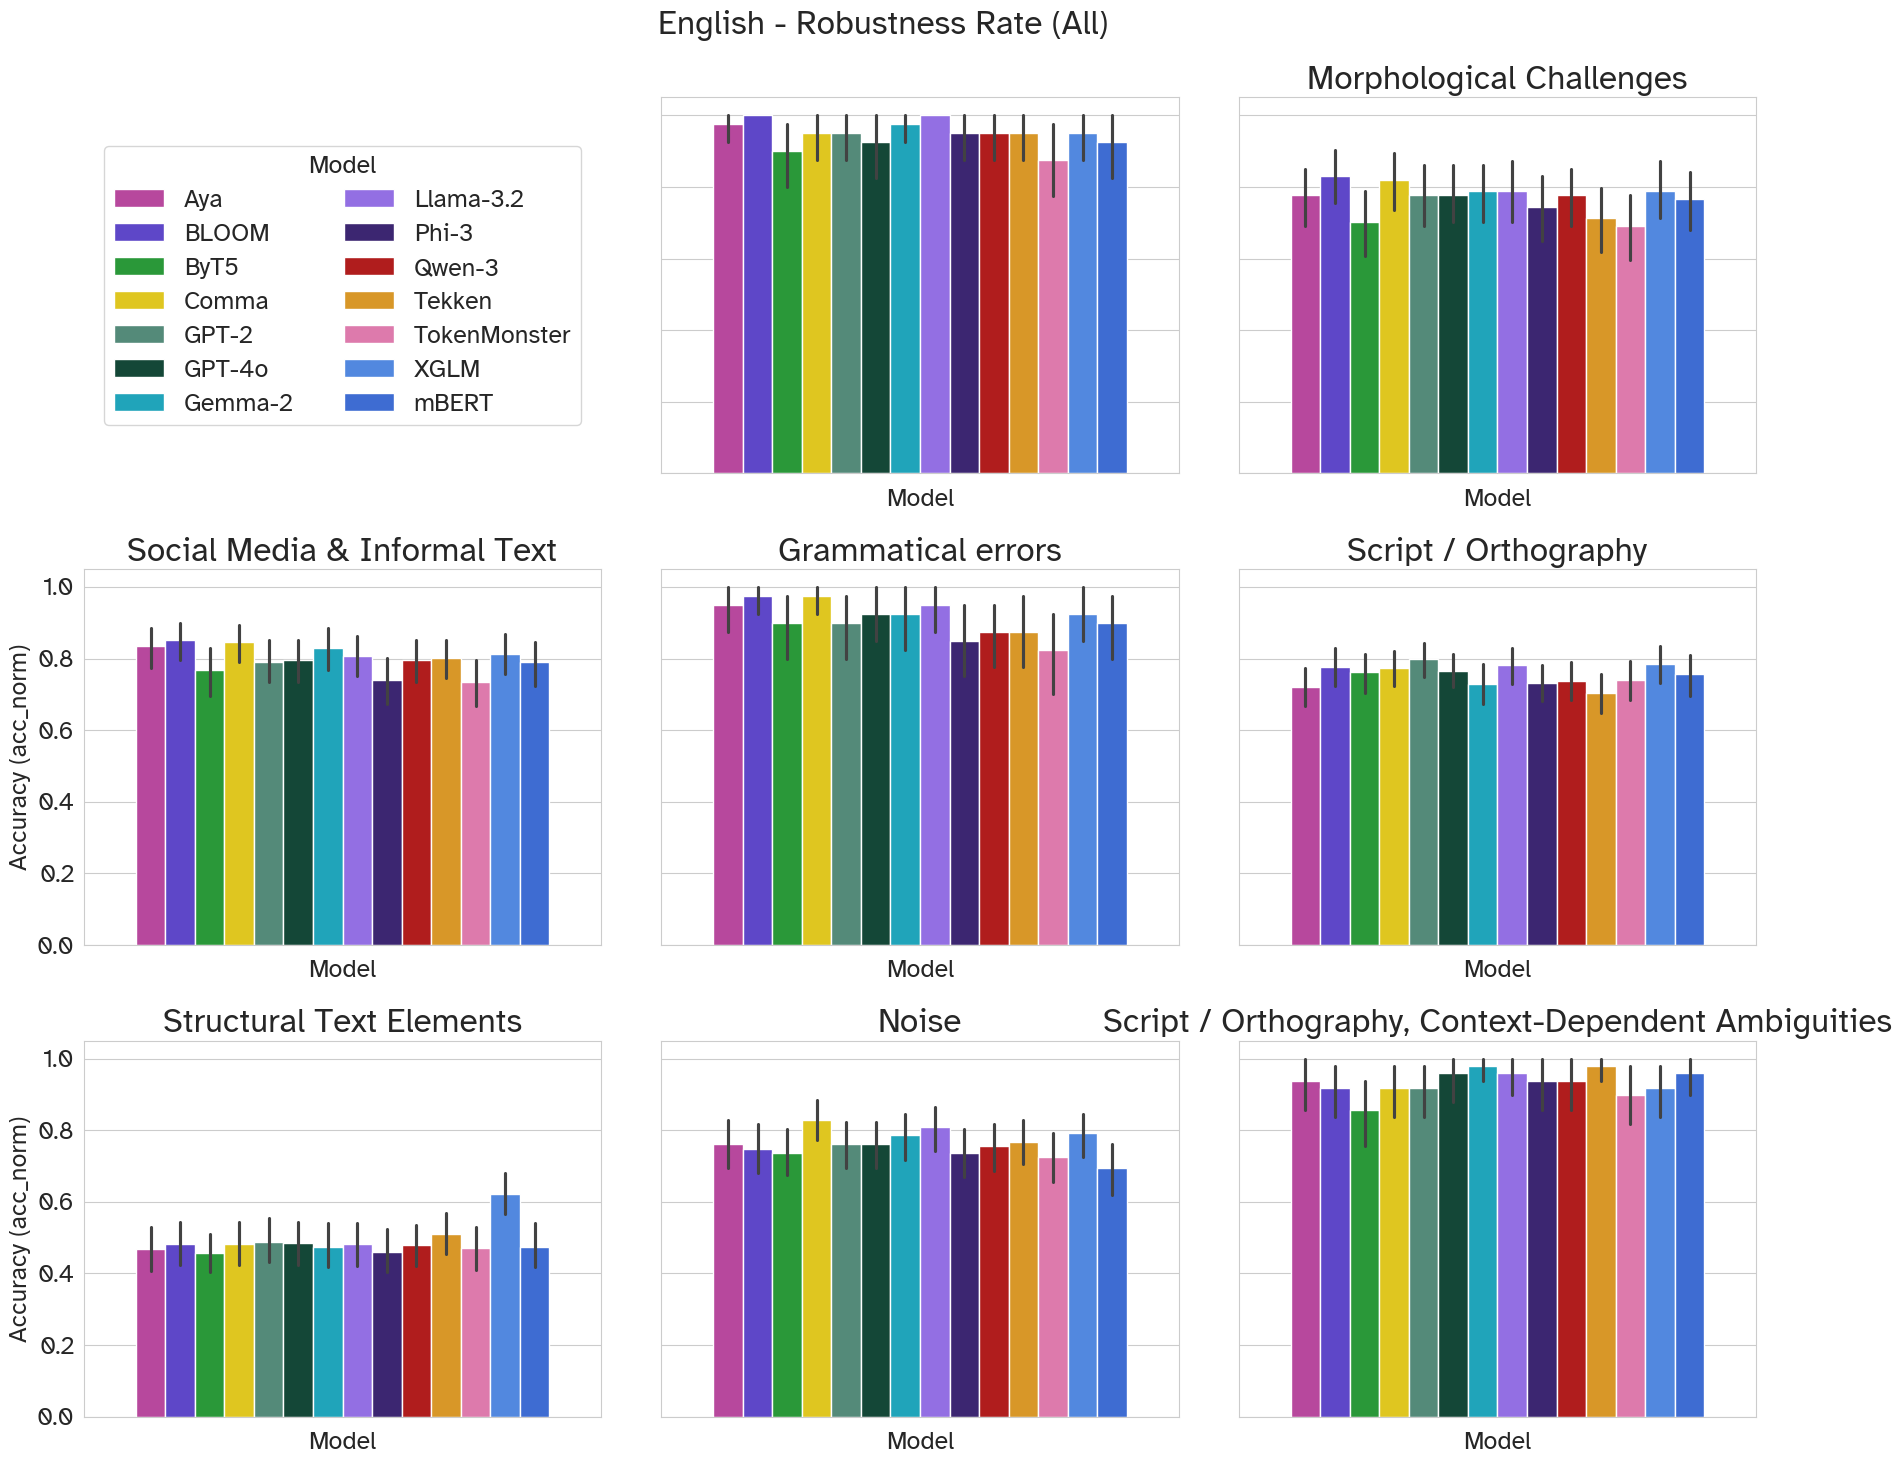

Plotting Script / Orthography, Language Contact into position 0
9 False False
Plotting Script / Orthography, Mathematical & Scientific Notation into position 1
10 False False
Plotting Temporal Expressions into position 2
11 False False
Plotting Mathematical & Scientific Notation into position 3
12 False False
Plotting Morphological Challenges, Mathematical & Scientific Notation into position 4
13 False False
Plotting Script / Orthography, Language Contact, Script / Orthography into position 5
14 False False
Plotting Mathematical & Scientific Notation, Context-Dependent Ambiguities into position 6
15 False False
Plotting Morphological Challenges, Script / Orthography, Context-Dependent Ambiguities into position 7
16 False False
Plotting Script / Orthography, Morphological Challenges into position 8
17 False True


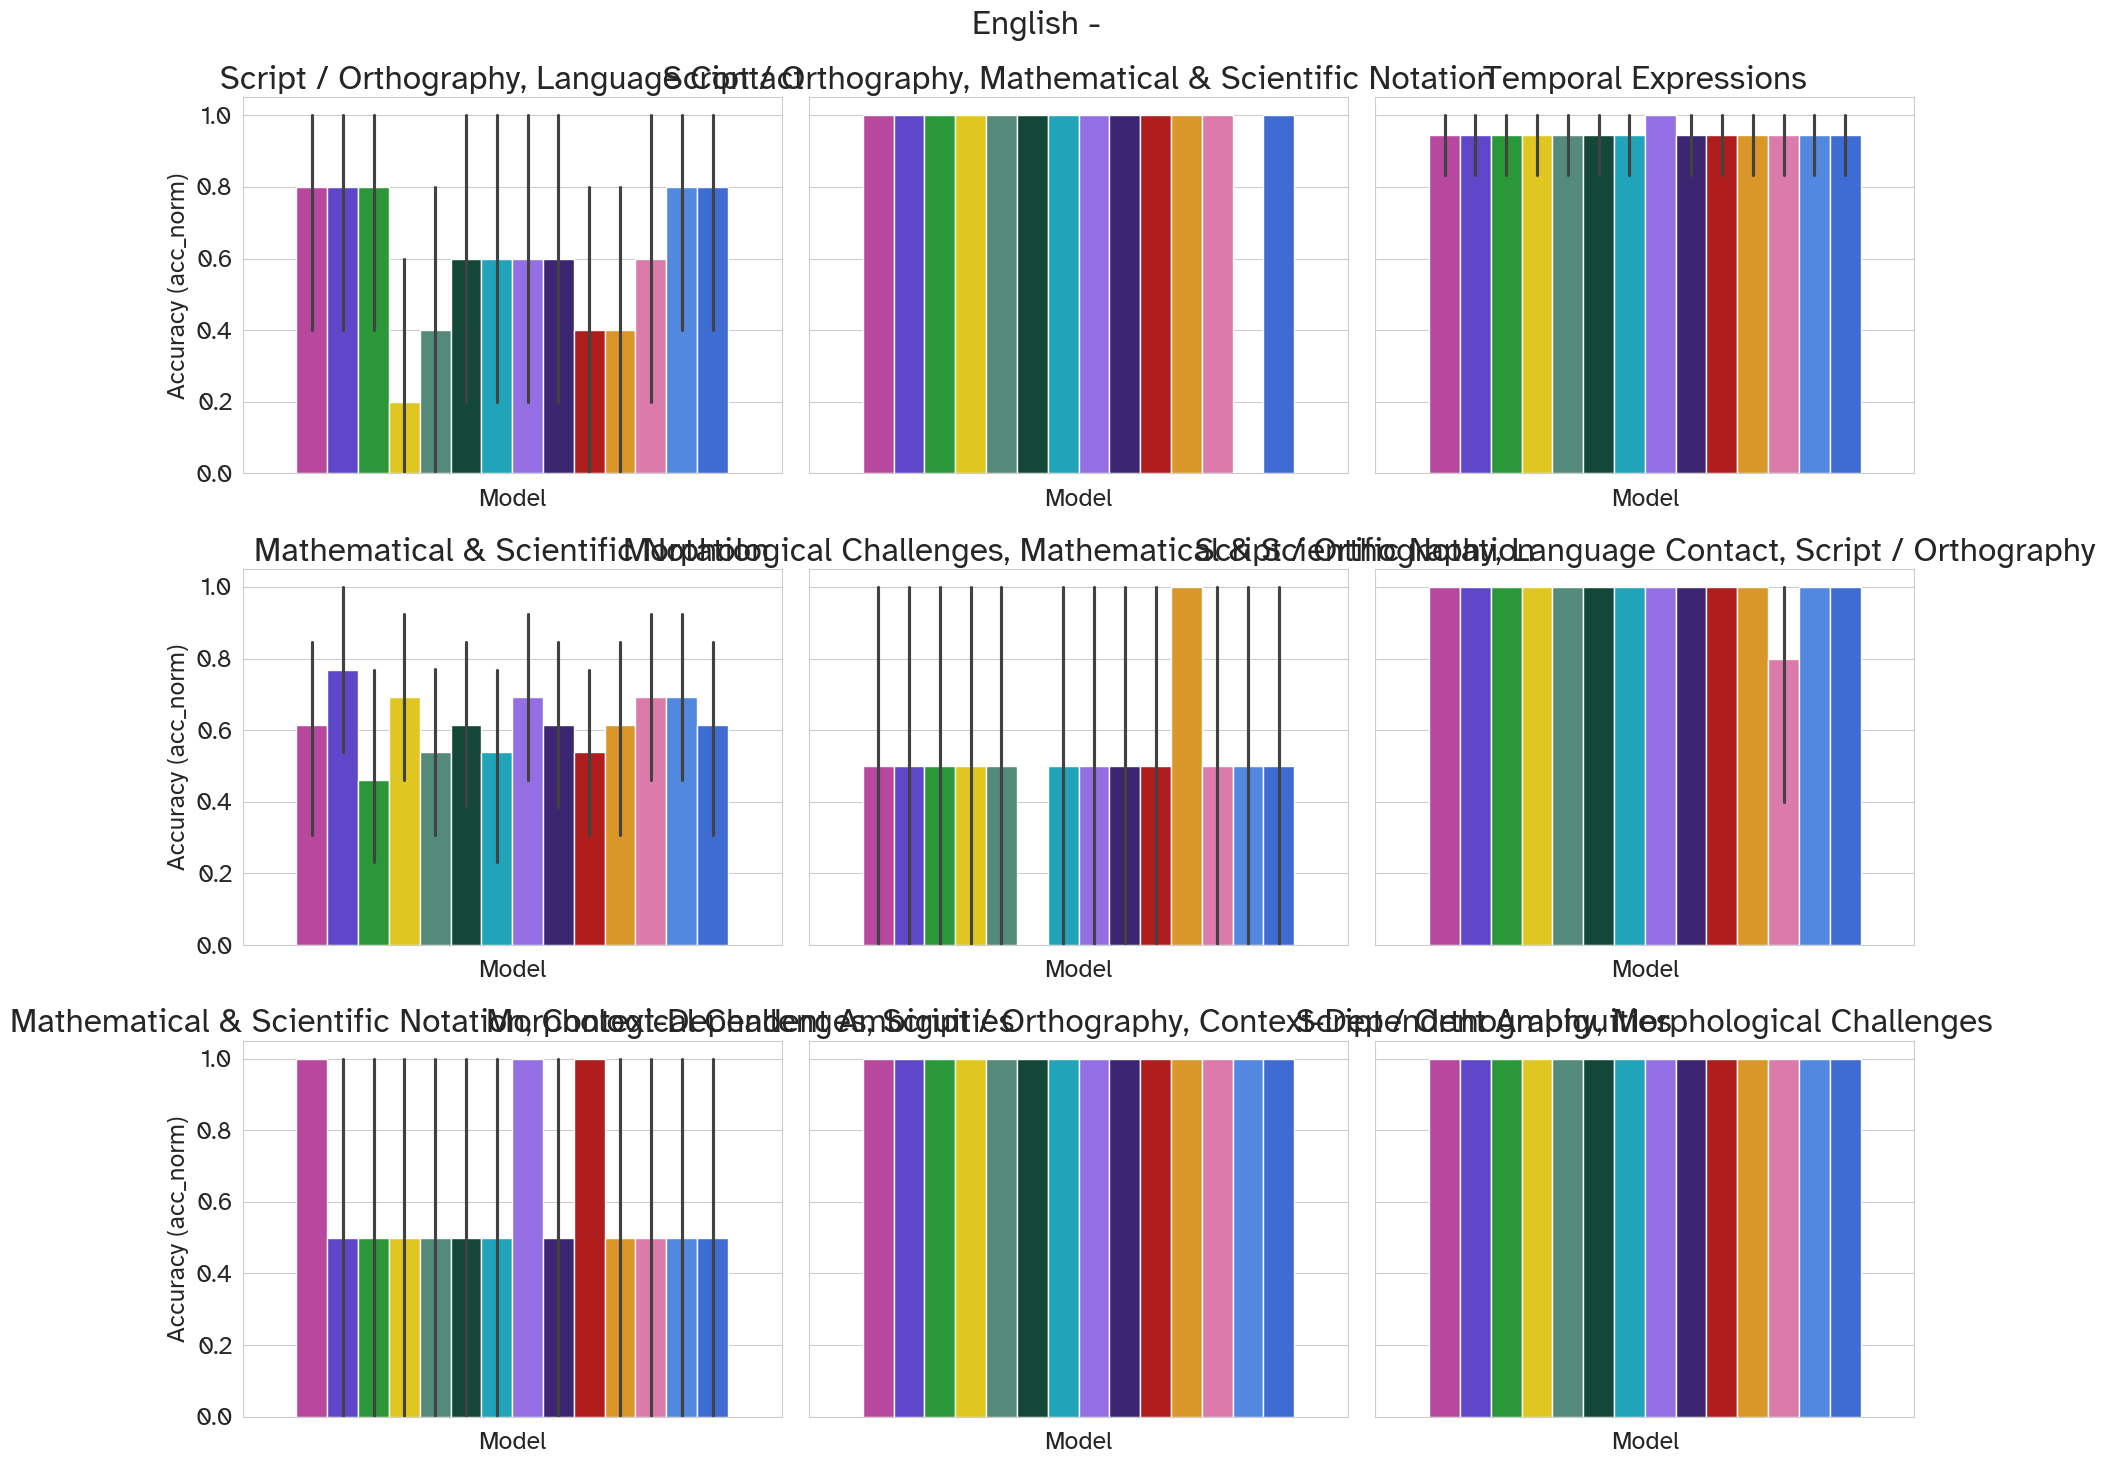

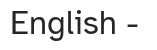

                                          acc_norm
model_name task_pretty_name                       
Aya        Abbreviations                  0.702703
           Canonical                      0.975000
           Capitalization                 0.825000
           Character deletion             0.800000
           Character substitution         1.000000
...                                            ...
mBERT      Spaced styling                 0.375000
           Spelled out                    0.600000
           Superscript/subscript styling  0.325000
           Web search query               0.621622
           Word reordering                0.850000

[406 rows x 1 columns]


In [ ]:
nrows, ncols = 3, 3
fig, axs = get_new_fig(
    nrows=nrows, ncols=ncols, title=f"{title_pattern}Robustness Rate {suffix}"
)
fig_cnt = 0
PLOT_AXIS = "model_name"
# PLOT_AXIS = "vocab_bucket"
palette = MODEL_TO_COLOR if PLOT_AXIS == "model_name" else None
## category might have multiple entries
FILTER_AXIS = "category"

samples = samples.sort_values(["model_name", "set_id", "variation_id"])
tasks = samples[FILTER_AXIS].unique()
for i, task in enumerate(tasks, 1):
    print(f"Plotting {task} into position {i % len(axs)}")
    filter_ = samples[FILTER_AXIS] == task
    tmp = samples[filter_]
    ax = axs[i % len(axs)]
    sns.barplot(
        tmp, hue=PLOT_AXIS, y=METRIC,ax=ax, legend=i == 1, palette=palette
    )
    ax.set_xlabel("Model")
    ax.set_ylabel(f"Accuracy ({METRIC})")
    title = task
    ax.set_title(title)
    # Check if we need to show the current figure
    is_last_task = i == len(tasks) + 1
    is_end_of_6 = (i + 1) % (nrows * ncols) == 0
    if i == 1:
        # Add legend to the first subplot of current figure
        handles, labels = axs[1].get_legend_handles_labels()
        axs[0].clear()
        axs[0].axis("off")
        axs[0].legend(handles, labels, title="Model", loc="center", ncol=2)
        axs[1].legend().set_visible(False)
    print(i, is_last_task, is_end_of_6)
    if is_last_task or is_end_of_6:
        # Hide any unused subplots in the current figure
        if is_last_task:
            print(f"Last task: {i}, {task}")
            num_plots_in_current_fig = (i % ncols * nrows) + 1
            for j in range(num_plots_in_current_fig, ncols * nrows):
                axs[j].set_visible(False)
            break

        # Show the current figure
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR/f"by_task_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
        plt.show()
        fig, axs = get_new_fig(nrows=nrows, ncols=ncols, title=title_pattern)
        fig_cnt += 1
# Hide any unused subplots if there are fewer than 6 tasks
for j in range((len(tasks) + 1) % (ncols * nrows), ncols * nrows):
    axs[j].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig(OUTPUT_DIR/f"by_task_by_{PLOT_AXIS.lower()}_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
plt.show()

print(accuracies_by_model)

## Canonical Eng vs Other Langs

In [33]:
samples[samples["is_canonical"] & (samples["Lang"] == "ita_Latn")]["set_id"]

Series([], Name: set_id, dtype: float64)

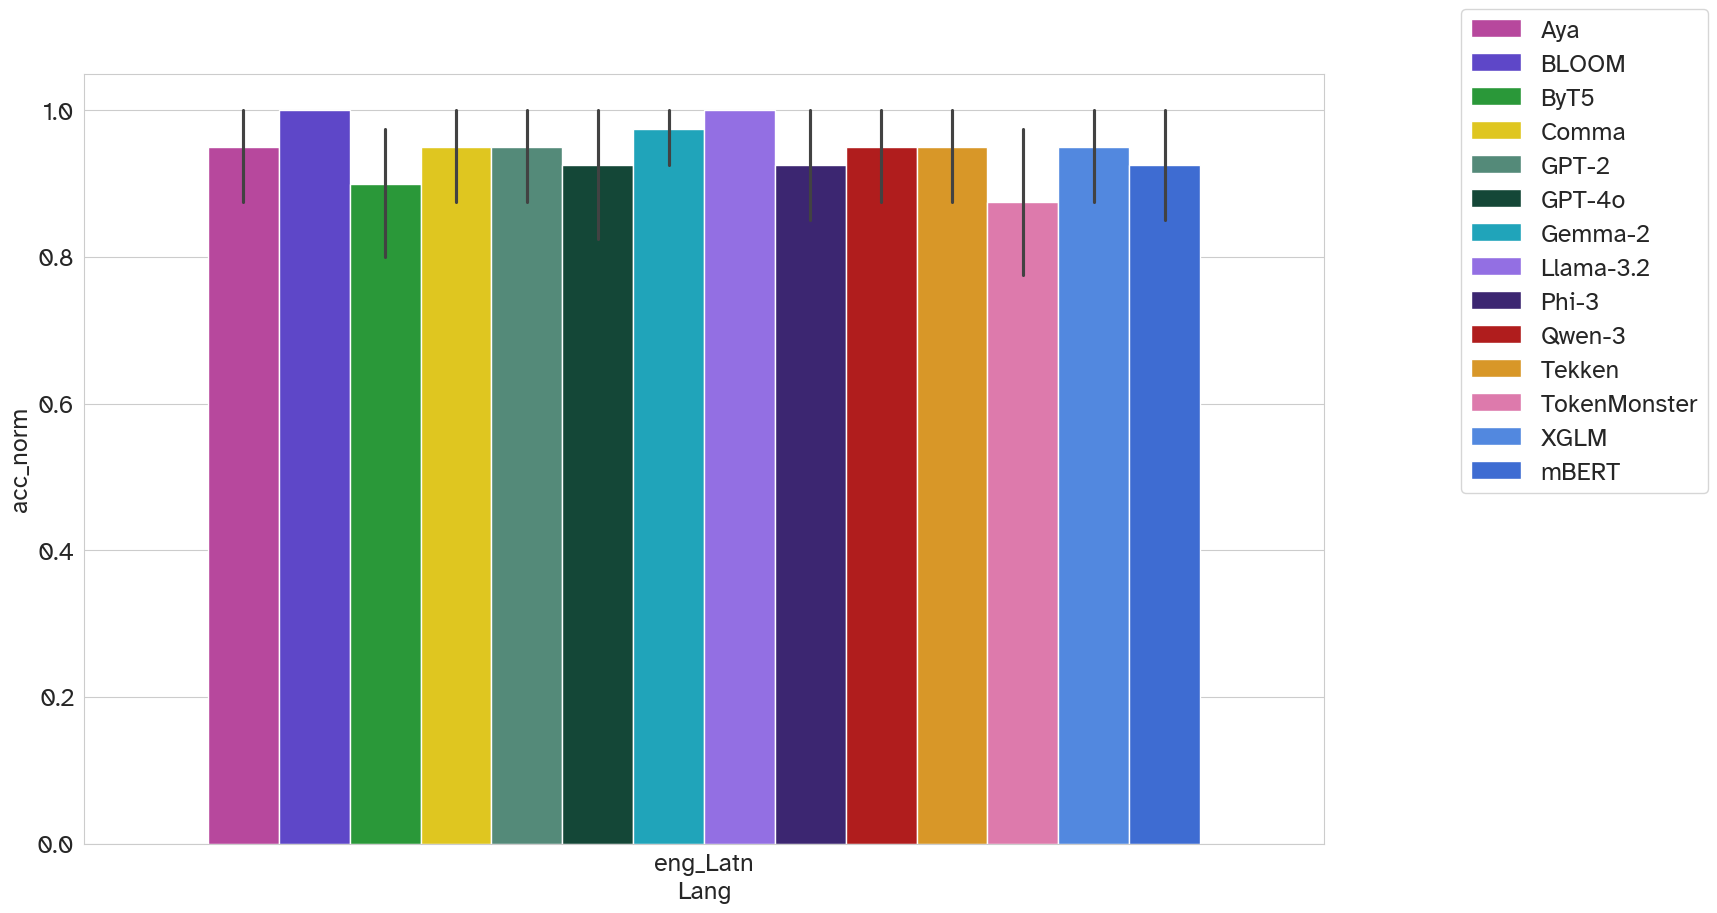

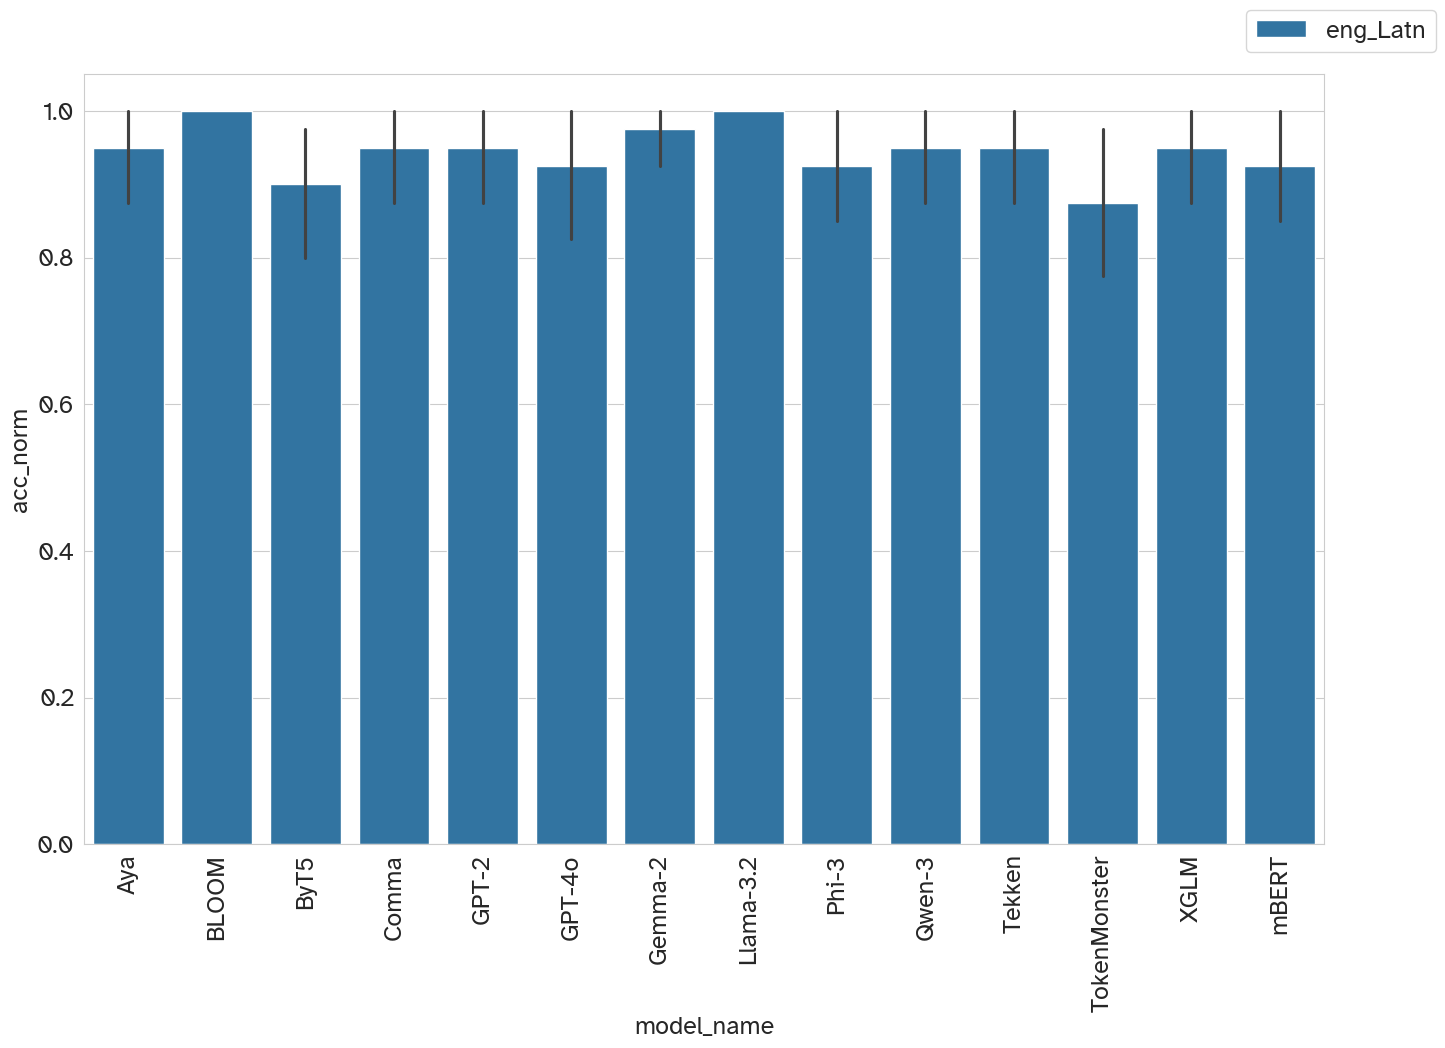

| Lang     |   acc_norm |
|:---------|-----------:|
| eng_Latn |   0.944643 |


In [34]:
filter_ = samples["is_canonical"] & (samples["set_id"].isin(list(range(300,345)) + [str(i) for i in range(300, 345)]))

fig = plt.figure(figsize=(16, 10))
sns.barplot(samples[filter_], x="Lang", y=METRIC, hue="model_name", palette=MODEL_TO_COLOR)
plt.legend(bbox_to_anchor=(1.1,1.1))
plt.show()

fig = plt.figure(figsize=(16, 10))
sns.barplot(samples[filter_], x="model_name", y=METRIC, hue="Lang")
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.1,1.1))
plt.show()

print(samples[filter_].pivot_table(index=["Lang"], values=METRIC, aggfunc="mean").sort_values(METRIC, ascending=False).to_markdown())

In [35]:
# samples["Lang"].unique()
samples[filter_ & (samples["model_name"] == "mBERT")]

,doc_id,target,resps,metrics,acc,acc_norm,model_name,tokenizer_name,task,Lang,...,token_counts.gpt2,token_counts.meta-llama/Llama-3.2-1B,token_counts.microsoft/Phi-3-mini-4k-instruct,token_counts.mistralai/tekken,token_counts.tiktoken/gpt-4o,token_counts.tokenmonster/englishcode-32000-consistent-v1,task_pretty_name,vocab_bucket,is_canonical,var_id
11774,0,0,"[[[-3.390625, False]], [[-6.46875, False]], [[...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_cannon...,eng_Latn,...,12,11,13,11,12,11,Canonical,Medium,True,0.0
11775,1,1,"[[[-4.6875, False]], [[-2.4375, True]], [[-4.8...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_cannon...,eng_Latn,...,6,6,6,6,6,5,Canonical,Medium,True,0.0
11776,2,3,"[[[-14.1875, False]], [[-10.8125, False]], [[-...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_cannon...,eng_Latn,...,18,19,24,23,19,17,Canonical,Medium,True,0.0
11777,3,1,"[[[-11.9375, False]], [[-7.875, False]], [[-10...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_cannon...,eng_Latn,...,13,14,19,18,13,14,Canonical,Medium,True,0.0
11778,4,1,"[[[-4.5625, False]], [[-4.4375, False]], [[-3....","[acc, acc_norm]",0,0,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_cannon...,eng_Latn,...,7,7,8,7,7,6,Canonical,Medium,True,0.0
11779,5,1,"[[[-6.03125, False]], [[-0.283203125, True]], ...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_cannon...,eng_Latn,...,6,6,6,6,6,5,Canonical,Medium,True,0.0
11780,6,0,"[[[-3.640625, False]], [[-6.09375, False]], [[...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_cannon...,eng_Latn,...,8,8,8,8,8,6,Canonical,Medium,True,0.0
11781,7,3,"[[[-8.0625, False]], [[-7.78125, False]], [[-7...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_cannon...,eng_Latn,...,8,8,8,8,8,6,Canonical,Medium,True,0.0
11782,8,3,"[[[-8.8125, False]], [[-8.75, False]], [[-8.87...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_cannon...,eng_Latn,...,8,8,8,8,8,7,Canonical,Medium,True,0.0
11783,9,1,"[[[-6.15625, False]], [[-4.875, False]], [[-7....","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_cannon...,eng_Latn,...,8,9,9,9,9,7,Canonical,Medium,True,0.0


### By Model

In [36]:
OUTPUT_DIR.absolute()

PosixPath('/Users/gsaltintas/code/phd/tokenizers/notebooks/output/prelim-results-v3/english/all')

Plotting Aya into position 1
Plotting BLOOM into position 2
Plotting ByT5 into position 3
Plotting Comma into position 4


/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_20288/3813602609.py:42: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


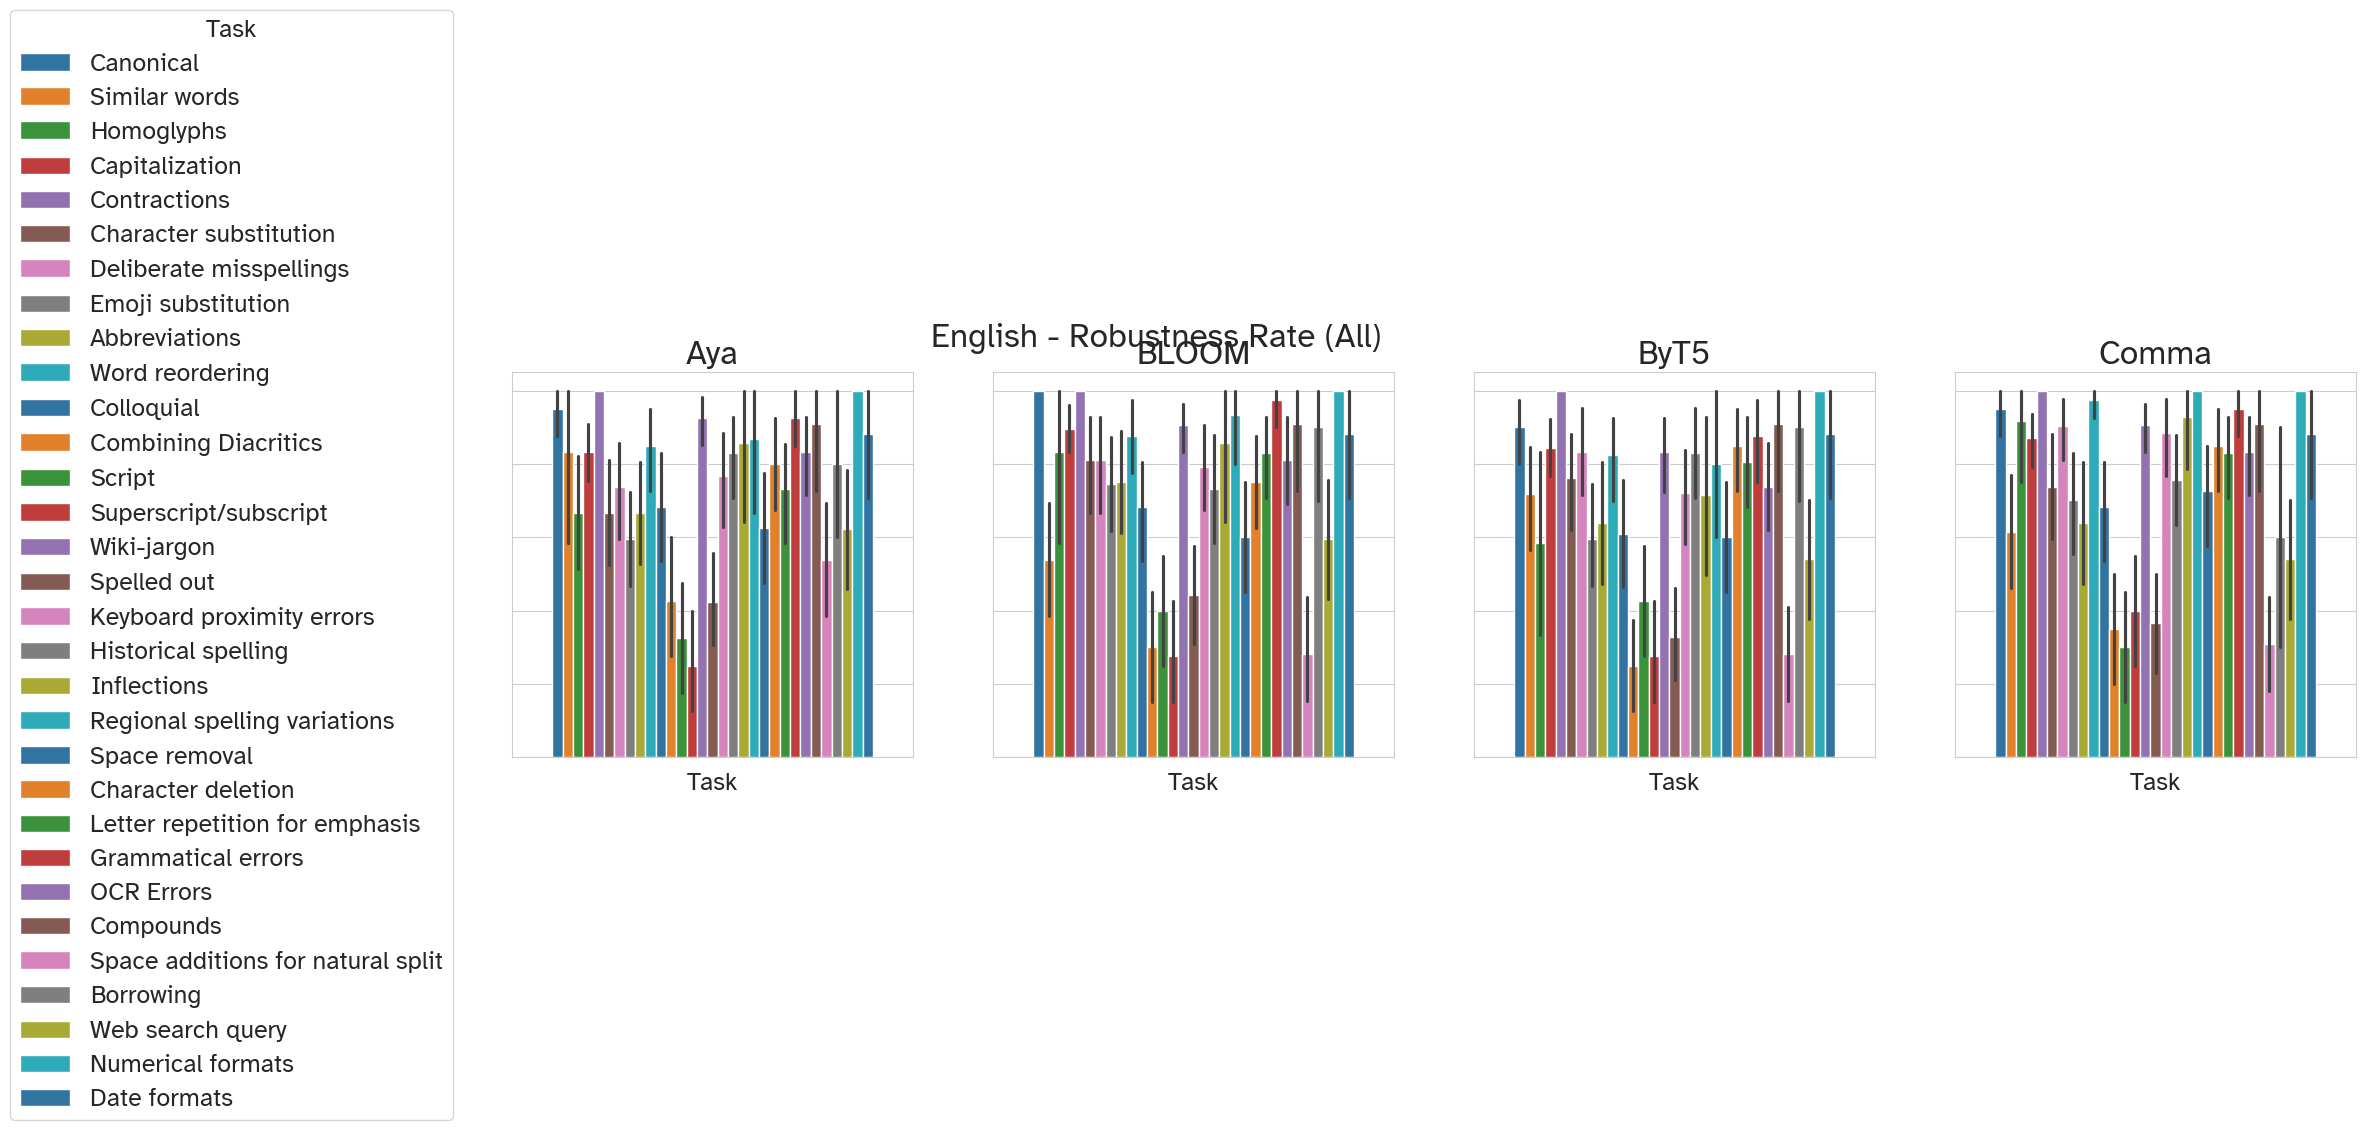

Plotting GPT-2 into position 0
Plotting GPT-4o into position 1
Plotting Gemma-2 into position 2
Plotting Llama-3.2 into position 3
Plotting Phi-3 into position 4


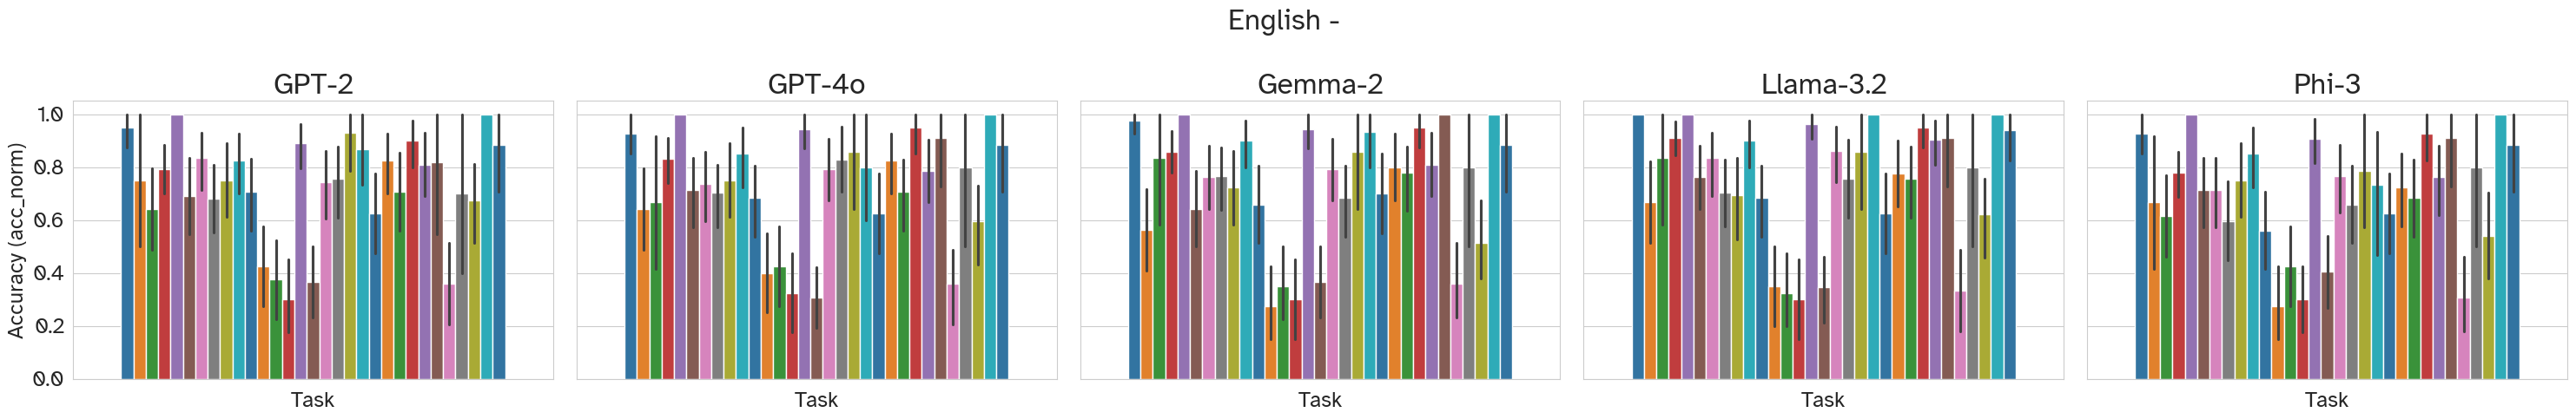

Plotting Qwen-3 into position 0
Plotting Tekken into position 1
Plotting TokenMonster into position 2
Plotting XGLM into position 3
Plotting mBERT into position 4


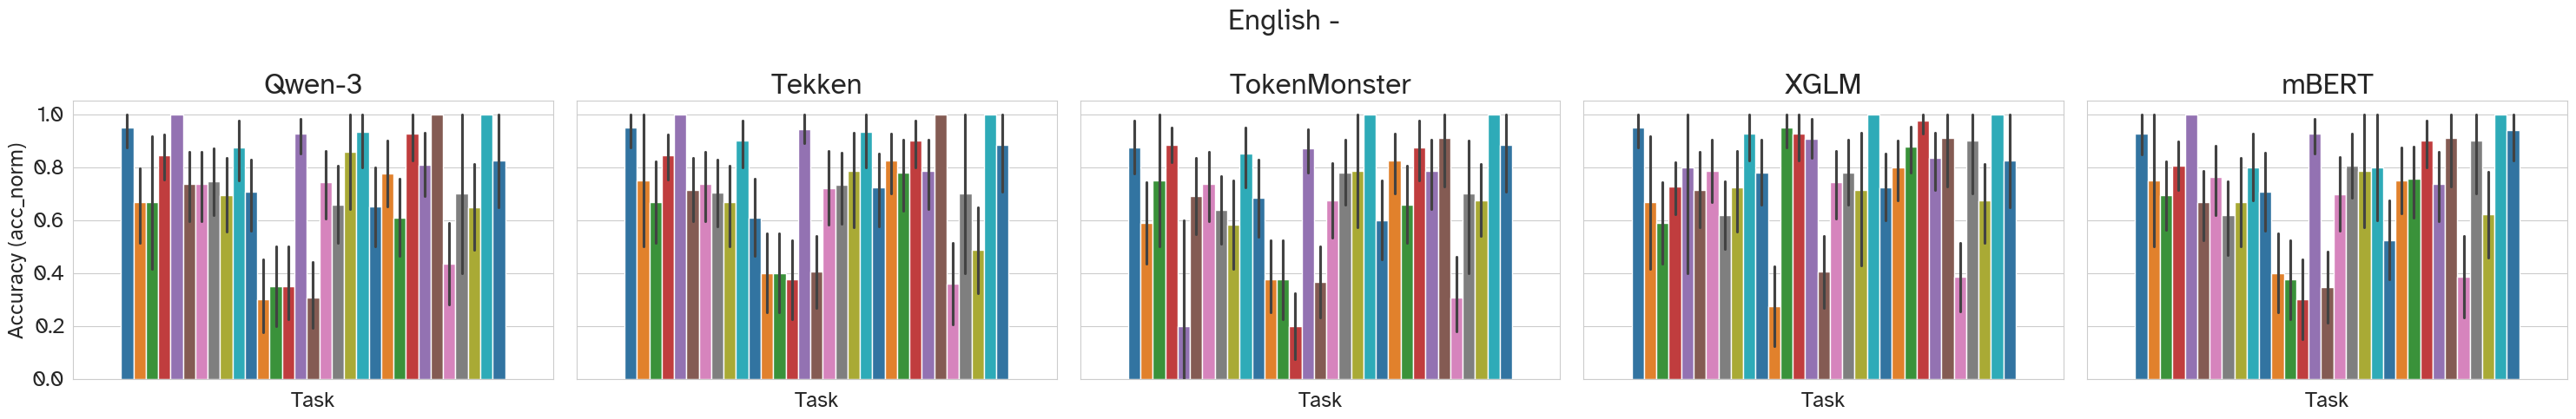

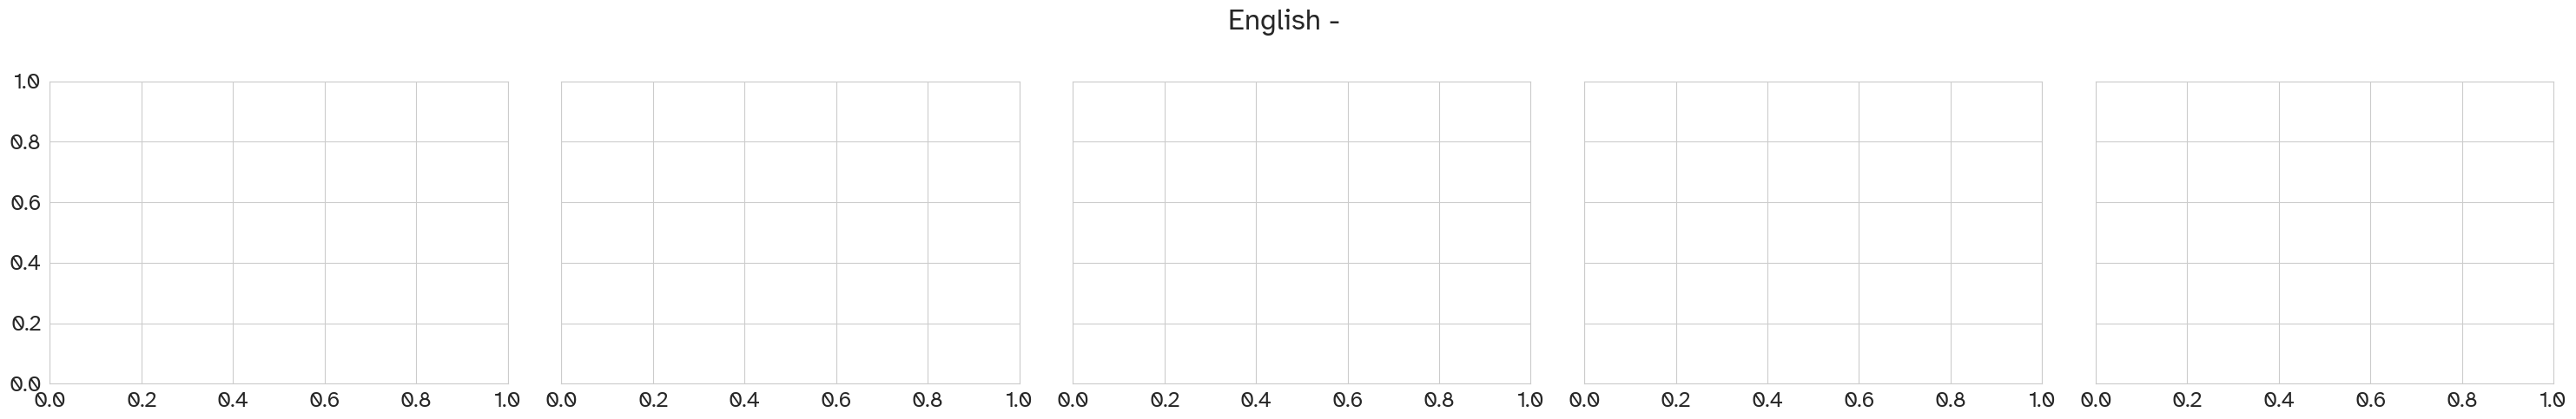

                                  acc_norm
model_name task_pretty_name               
Aya        Abbreviations          0.666667
           Borrowing              0.800000
           Canonical              0.950000
           Capitalization         0.831169
           Character deletion     0.800000
...                                    ...
mBERT      Spelled out            0.346154
           Superscript/subscript  0.300000
           Web search query       0.621622
           Wiki-jargon            0.925926
           Word reordering        0.800000

[434 rows x 1 columns]


In [37]:
nrows, ncols = 1, 5
PLOT_AXIS="model_name"
# PLOT_AXIS="vocab_bucket"
HUE="task_pretty_name"
# HUE="task"
fig, axs = get_new_fig(
    nrows=nrows, ncols=ncols, title=f"{title_pattern}Robustness Rate {suffix}"
)
fig_cnt = 0
models = samples[PLOT_AXIS].unique()
sorted(models)
for i, model in enumerate(models, 1):
    print(f"Plotting {model} into position {i % len(axs)}")
    filter_ = samples[PLOT_AXIS] == model
    tmp = samples[filter_]
    ax = axs[i % len(axs)]
    sns.barplot(
        tmp, hue=HUE, y=METRIC, palette="tab10", ax=ax, legend=i == 1
    )
    ax.set_xlabel("Task")
    ax.set_ylabel(f"Accuracy ({METRIC})")
    title=model
    ax.set_title(title)
    # Check if we need to show the current figure
    is_last_task = i == len(models) + 1
    is_end_of_6 = (i + 1) % (nrows * ncols) == 0
    if i == 1:
        # Add legend to the first subplot of current figure
        handles, labels = axs[1].get_legend_handles_labels()
        axs[0].clear()
        axs[0].axis("off")
        axs[0].legend(handles, labels, title="Task", loc="center", ncol=1)
        axs[1].legend().set_visible(False)
    if is_last_task or is_end_of_6:
        # Hide any unused subplots in the current figure
        if is_last_task:
            num_plots_in_current_fig = (i % ncols * nrows) + 1
            for j in range(num_plots_in_current_fig, ncols * nrows):
                axs[j].set_visible(False)

        # Show the current figure
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR/f"by_model_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
        plt.show()
        fig_cnt += 1
        fig, axs = get_new_fig(nrows=nrows, ncols=ncols, title=title_pattern)
# Hide any unused subplots if there are fewer than 6 tasks
# for j in range((len(models)+1) % (ncols * nrows), ncols * nrows):
#     axs[j].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig(OUTPUT_DIR/f"by_model_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")

plt.show()

print(accuracies_by_model)

### Examples per perturbation

In [38]:
pv = all_samples[all_samples["model_name"] == "Aya"].pivot_table(index=["model_name", "task_pretty_name"], values=METRIC, aggfunc="count")
pv.to_csv(OUTPUT_DIR/"sample_counts.csv")
pv


acc_norm
model_name task_pretty_name                           
Aya        Abbreviations                            36
           Borrowing                                10
           Canonical                                40
           Capitalization                           77
           Character deletion                       40
           Character substitution                   42
           Colloquial                               41
           Combining Diacritics                     40
           Compounds                                11
           Contractions                              5
           Date formats                             17
           Deliberate misspellings                  42
           Emoji substitution                       47
           Grammatical errors                       40
           Historical spelling                      41
           Homoglyphs                               39
           Inflections                              14
           Keyboard proximity errors                43
           Letter repetition for emphasis           41
           Numerical formats                         5
           OCR Errors                               42
           Regional spelling variations             15
           Script                                   40
           Similar words                            12
           Space additions for natural split        39
           Space removal                            40
           Spelled out                              52
           Superscript/subscript                    40
           Web search query                         37
           Wiki-jargon                              54
           Word reordering                          40

### Against tokenizer props

#### Token count

In [39]:
models = samples["model_name"].unique()

sns.histplot(samples, x="model_name", y="token_counts")

ValueError: Could not interpret value `token_counts` for `y`. An entry with this name does not appear in `data`.

In [ ]:
samples.columns

Index(['doc_id', 'target', 'resps', 'metrics', 'acc', 'acc_norm', 'model_name',
       'task', 'question', 'choices', 'answer', 'answer_label', 'split',
       'subcategories', 'categories', 'lang', 'second_lang', 'notes', 'id',
       'set_id', 'variation_id',
       'vanilla_cos_sim_to_canonical.CohereLabs/aya-expanse-8b',
       'vanilla_cos_sim_to_canonical.Qwen/Qwen3-8B',
       'vanilla_cos_sim_to_canonical.bigscience/bloom',
       'vanilla_cos_sim_to_canonical.common-pile/comma-v0.1-1t',
       'vanilla_cos_sim_to_canonical.facebook/xglm-564M',
       'vanilla_cos_sim_to_canonical.google-bert/bert-base-multilingual-cased',
       'vanilla_cos_sim_to_canonical.google/byt5-small',
       'vanilla_cos_sim_to_canonical.google/gemma-2-2b',
       'vanilla_cos_sim_to_canonical.gpt2',
       'vanilla_cos_sim_to_canonical.meta-llama/Llama-3.2-1B',
       'vanilla_cos_sim_to_canonical.microsoft/Phi-3-mini-4k-instruct',
       'vanilla_cos_sim_to_canonical.mistralai/tekken',
       'vani

In [ ]:
toks = samples["tokenizer_name"].unique()
tok_count_cols = [f"token_counts.{tok_name}" for tok_name in toks]
tok_counts = samples[tok_count_cols]
tok_counts.columns=toks
tok_counts 


,google/byt5-small,bigscience/bloom,common-pile/comma-v0.1-1t,google-bert/bert-base-multilingual-cased,Qwen/Qwen3-8B,gpt2,CohereLabs/aya-expanse-8b
0,80,35,41,25,23,42,22
1,26,11,12,9,10,15,6
2,20,8,9,7,8,12,5
3,49,22,26,19,25,22,23
4,40,14,23,13,22,20,20
...,...,...,...,...,...,...,...
4076,30,12,13,7,10,13,6
4077,29,10,10,7,9,12,5
4078,18,8,10,6,6,11,5
4079,27,10,13,9,10,14,7


In [ ]:
samples["tokenizer_name"]

0               google/byt5-small
1               google/byt5-small
2               google/byt5-small
3               google/byt5-small
4               google/byt5-small
                  ...            
4076    CohereLabs/aya-expanse-8b
4077    CohereLabs/aya-expanse-8b
4078    CohereLabs/aya-expanse-8b
4079    CohereLabs/aya-expanse-8b
4080    CohereLabs/aya-expanse-8b
Name: tokenizer_name, Length: 4081, dtype: object

In [ ]:
for i, row in samples.iterrows():
    samples.iloc[i, "token_count"]=

,doc_id,target,resps,metrics,acc,acc_norm,model_name,tokenizer_name,task,question,...,token_counts.google/gemma-2-2b,token_counts.gpt2,token_counts.meta-llama/Llama-3.2-1B,token_counts.microsoft/Phi-3-mini-4k-instruct,token_counts.mistralai/tekken,token_counts.tiktoken/gpt-4o,token_counts.tokenmonster/englishcode-32000-consistent-v1,answer_choice,task_pretty_name,is_canonical
0,0,0,"[[[-7.9375, False]], [[-15.0625, False]], [[-1...","[acc, acc_norm]",1,1,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Dr Gülçiçek Bölükbaşı bir doktordur. Gülçiçek ...,...,23,42,28,37,26,26,54,doktorluktur,Derivations,False
1,1,2,"[[[-11.875, False]], [[-12.1875, False]], [[-1...","[acc, acc_norm]",1,0,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Gökyüzünün renklenişi,...,7,15,8,12,9,8,17,mavidir,Derivations,False
2,2,3,"[[[-7.21875, False]], [[-11.0625, False]], [[-...","[acc, acc_norm]",0,0,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Gökyüzünün rengi,...,5,12,8,9,8,6,14,mavimsidir,Derivations,False
3,3,0,"[[[-8.5625, False]], [[-16.25, False]], [[-18....","[acc, acc_norm]",1,1,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,"Bu ev 5,850,000 Lira fiyatlı. Bu evin maaliyeti",...,22,22,20,28,25,20,24,"5,850,000 TL'dir",Derivations,False
4,4,3,"[[[-13.8125, False]], [[-13.9375, False]], [[-...","[acc, acc_norm]",0,0,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Bugün 17/08/1998'dir. Bugünkü tarihi,...,20,20,16,24,21,16,25,17/8/1998'dir,Derivations,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4076,6,0,"[[[-16.75, False]], [[-12.625, False]], [[-12....","[acc, acc_norm]",0,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Bir dakikadaki saniye sayısı,...,9,13,8,13,9,9,16,altmıştır,Spelled out,False
4077,7,2,"[[[-9.0625, False]], [[-8.125, False]], [[-8.5...","[acc, acc_norm]",0,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Bir altıgenin kenar sayısı,...,8,12,7,12,9,9,16,altıdır,Spelled out,False
4078,8,2,"[[[-11.6875, False]], [[-14.4375, False]], [[-...","[acc, acc_norm]",0,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Yüzün yüzde onu,...,5,11,5,10,6,5,11,ondur,Spelled out,False
4079,9,0,"[[[-11.875, False]], [[-15.375, False]], [[-16...","[acc, acc_norm]",1,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Seksenin yüzde yirmi beşi,...,9,14,10,14,11,9,16,yirmidir,Spelled out,False
